# $^{171}$Yb shelving 后 `c-r` 段 Gaussian 边沿 time-optimal 扫描

本 notebook 是 workflow 第一阶段产物，只保留两个结果分支：

1. **闭系统无噪声 direct phase-control coarse scan**。
2. **加入 Rydberg decay，寿命 $T_r=65\,\mu\mathrm{s}$ 的开放系统诊断**。

已删除所有其它中间优化分支与派生图表，以免审阅时混淆。

## Goal and Current Caveat

目标是比较固定峰值 Rabi 频率下，每侧 Gaussian 上升/下降沿长度对 CZ gate 的影响。

**符号约定**：Hamiltonian 中的 $\Omega_{\max}$ 是角频率，单位 rad/s；图中和代码变量 `omega_max_mhz` 标出的 `5, 10, 20 MHz` 是

$$
\Omega_{\max}/2\pi = 5,10,20\ \mathrm{MHz}.
$$

这与 LaTeX workbench `report-01-laser-control-system` 的定义一致：理论公式使用角频率 $\Omega$，实验数值通常报告 $\Omega/2\pi$。

本 notebook 保留的闭系统和开放系统 decay 结果都使用直接离散相位控制变量；不再保留任何余弦基、多频基或其它 basis-function 参数化结果。


## Physical States and Experimental Mapping

实验量子数采用 Muniz et al. 的门图像：

- `|0>`：ground nuclear-spin qubit state，$|{}^1S_0,m_F=-1/2\rangle$。
- `|1>`：ground nuclear-spin qubit state，$|{}^1S_0,m_F=+1/2\rangle$。
- `|c>`：metastable clock state，$|{}^3P_0,m_F=-1/2\rangle$，由 clock shelving pulse 从 `|1>` 选择性转移而来。
- `|r>`：Rydberg state，$|65\,{}^3S_1,F=3/2,m_F=-3/2\rangle$。

本 notebook 假设 shelving / unshelving 理想，只研究 UV 段：

```text
0 |00>
1 |01_c>   representative for |0c> and |c0>
2 |01_r>   representative for |0r> and |r0>
3 |11_cc>  |cc>
4 |11_Wcr> (|cr>+|rc>)/sqrt(2)
5 |11_rr>  |rr>
```

计算 representative indices 为 `(0, 1, 3)`，权重为 `(1, 2, 1)`。

## Hamiltonian and Time Units

闭系统 Hamiltonian 为

$$
H(t)=H_d+A(t)\cos\phi(t)H_x+A(t)\sin\phi(t)H_y.
$$

程序内部使用无量纲时间

$$
\tau=\Omega_{\max}t,\qquad \Omega_{\max}=2\pi f_\Omega.
$$

`omega_max_mhz=10` 表示 $f_\Omega=10\,\mathrm{MHz}$，也就是 $\Omega_{\max}=2\pi\times10\,\mathrm{MHz}$。默认 blockade 为

$$
V/2\pi=160\,\mathrm{MHz},\qquad V/\Omega_{\max}=160/f_\Omega.
$$

因此 $f_\Omega=5,10,20\,\mathrm{MHz}$ 时，程序中的 blockade 分别是 `32,16,8`。

## Edge Definition

`edge_ns` 是**单侧** Gaussian 上升沿时间；下降沿也使用同样长度。因此 rise+fall 总边沿时间是 `2*edge_ns`。

设总 UV 段时间为 $T$，单侧边沿长度为 $t_e$。程序使用归一化振幅包络 $A(t)\in[0,1]$，实际 Rabi 角频率为

$$
\Omega(t)=\Omega_{\max}A(t).
$$

当前 Gaussian edge 的定义为

$$
A(t)=
\begin{cases}
\dfrac{
\exp\left[-\dfrac{(t-t_e)^2}{2\sigma^2}\right]
-
\exp\left[-\dfrac{t_e^2}{2\sigma^2}\right]
}{
1-\exp\left[-\dfrac{t_e^2}{2\sigma^2}\right]
},
& 0\le t<t_e,\\[1.2em]
1,
& t_e\le t\le T-t_e,\\[0.6em]
\dfrac{
\exp\left[-\dfrac{(t-(T-t_e))^2}{2\sigma^2}\right]
-
\exp\left[-\dfrac{t_e^2}{2\sigma^2}\right]
}{
1-\exp\left[-\dfrac{t_e^2}{2\sigma^2}\right]
},
& T-t_e<t\le T,
\end{cases}
$$

其中本 notebook 取

$$
\sigma=t_e/3.
$$

这样 $A(0)=A(T)=0$，$A(t_e)=A(T-t_e)=1$。`edge_ns=40` 指的是每一侧 40 ns；不是上升沿和下降沿相加后的 80 ns。`A(t)=1` 时实际 Rabi 角频率就是 $\Omega_{\max}$，图中用 MHz 标出的数值是 $\Omega(t)/2\pi$。


## Noise Model: Rydberg Decay in Time Evolution

闭系统使用 Schrodinger propagation：

$$
\psi_{k+1}=\exp[-iH(t_k)\Delta t] \psi_k.
$$

加入 Rydberg decay 时，本 notebook 使用 non-Hermitian no-jump generator：

$$
G(t)=-iH(t)-\frac{1}{2}\Gamma,
\qquad
\psi_{k+1}=\exp[G(t_k)\Delta t]\psi_k.
$$

对 $T_r=65\,\mu\mathrm{s}$，

$$
\gamma=1/T_r,\qquad
\gamma/\Omega_{\max}=\frac{1}{\Omega_{\max}T_r}.
$$

在 reduced basis 中

$$
\Gamma=\mathrm{diag}(0,0,\gamma,0,\gamma,2\gamma).
$$

也就是 `|01_r>` 和 `|11_Wcr>` 各有一个 Rydberg 激发，decay rate 为 `gamma`；`|11_rr>` 有两个 Rydberg 激发，decay rate 为 `2 gamma`。这个处理等价于把 decay 流出 coherent active block；表中的 `loss_proxy = 1-active_population` 用作损失诊断。

## Code

In [ ]:
from __future__ import annotations

import csv
import json
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import expm, expm_frechet
from scipy.optimize import minimize


In [ ]:
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = Path.cwd().parent
output_dir = ROOT / "artifacts" / "v5" / "closed_cr_edge_time_optimal_scan"
output_dir.mkdir(parents=True, exist_ok=True)
output_dir


### Phase Utilities and Gaussian Envelope

These helpers define phase wrapping, phase smoothness penalties, and the Gaussian edge envelope used by both closed- and open-system calculations.

In [ ]:
def wrap_phase(phases: np.ndarray) -> np.ndarray:
    return (np.asarray(phases, dtype=np.float64) + np.pi) % (2.0 * np.pi) - np.pi


def unwrap_for_plot(phases: list[float]) -> np.ndarray:
    return np.unwrap(np.asarray(phases, dtype=np.float64))


def phase_regularization(
    phases: np.ndarray,
    smoothness_weight: float,
    curvature_weight: float,
) -> tuple[float, np.ndarray]:
    phases = np.asarray(phases, dtype=np.float64)
    cost = 0.0
    gradient = np.zeros_like(phases)
    if phases.size >= 2 and smoothness_weight > 0.0:
        delta = wrap_phase(phases[1:] - phases[:-1])
        cost += smoothness_weight * float(np.sum(delta**2))
        gradient[:-1] -= 2.0 * smoothness_weight * delta
        gradient[1:] += 2.0 * smoothness_weight * delta
    if phases.size >= 3 and curvature_weight > 0.0:
        delta = wrap_phase(phases[1:] - phases[:-1])
        curvature = wrap_phase(delta[1:] - delta[:-1])
        cost += curvature_weight * float(np.sum(curvature**2))
        gradient[:-2] += 2.0 * curvature_weight * curvature
        gradient[1:-1] -= 4.0 * curvature_weight * curvature
        gradient[2:] += 2.0 * curvature_weight * curvature
    return cost, gradient


def gaussian_edge_envelope_ns(
    num_tslots: int,
    total_time_ns: float,
    edge_time_ns: float,
    sigma_to_edge: float = 1.0 / 3.0,
) -> np.ndarray:
    grid = np.linspace(0.0, float(total_time_ns), int(num_tslots), endpoint=True, dtype=np.float64)
    if edge_time_ns <= 0.0:
        return np.ones(int(num_tslots), dtype=np.float64)

    edge = min(float(edge_time_ns), 0.499 * float(total_time_ns))
    sigma = max(edge * float(sigma_to_edge), 1e-9)
    envelope = np.ones_like(grid)
    edge_floor = math.exp(-0.5 * (edge / sigma) ** 2)
    left = grid < edge
    right = grid > float(total_time_ns) - edge
    if np.any(left):
        left_gaussian = np.exp(-0.5 * ((grid[left] - edge) / sigma) ** 2)
        envelope[left] = (left_gaussian - edge_floor) / max(1.0 - edge_floor, 1e-12)
    if np.any(right):
        right_gaussian = np.exp(-0.5 * ((grid[right] - (float(total_time_ns) - edge)) / sigma) ** 2)
        envelope[right] = (right_gaussian - edge_floor) / max(1.0 - edge_floor, 1e-12)
    envelope[0] = 0.0
    envelope[-1] = 0.0
    return np.clip(envelope, 0.0, 1.0).astype(np.float64)


### Unwrapped Phase 是什么意思

优化变量本身是每个 time slot 的物理激光相位 $\phi_k$。在程序里，相位会用 `wrap_phase(...)` 存在 $[-\pi,\pi]$ 区间内；这只是因为相位本来只在模 $2\pi$ 意义下有区别。

画图时如果直接画 wrapped phase，一条实际连续变化的曲线一旦穿过 $\pi$ 或 $-\pi$，数值会突然跳变接近 $2\pi$，视觉上看起来像不连续。`unwrap_for_plot(...)` 做的是 `numpy.unwrap`：只为画图把这些人为的 $2\pi$ 跳变展开，让相位轨迹看起来连续。

因此图中的 `Unwrapped phase` 不是新的优化约束，也不代表我们要求初末相位为 0 或要求相位在实数轴上绝对连续；它只是同一组 modulo $2\pi$ 相位控制的可视化方式。


### Closed-System GRAPE Optimizer

This class contains the Hamiltonian propagation, objective function, analytic Frechet-gradient calculation, and L-BFGS-B optimization over direct time-slot phases.

In [ ]:
class ClosedShelvedCRPhaseGRAPE:
    """Closed-system phase-only GRAPE for the shelved c-r CZ segment."""

    computational_indices = np.array([0, 1, 3], dtype=np.int64)
    weights = np.array([1.0, 2.0, 1.0], dtype=np.float64)
    alpha_coefficients = np.array([1.0, 1.0, 1.0], dtype=np.float64)
    beta_coefficients = np.array([0.0, 1.0, 2.0], dtype=np.float64)

    def __init__(
        self,
        omega_max_mhz: float,
        total_time_ns: float,
        edge_time_ns: float,
        *,
        num_tslots: int = 32,
        blockade_shift_mhz: float = 160.0,
        smoothness_weight: float = 1e-4,
        curvature_weight: float = 1e-4,
    ) -> None:
        self.omega_max_mhz = float(omega_max_mhz)
        self.total_time_ns = float(total_time_ns)
        self.edge_time_ns = float(edge_time_ns)
        self.num_tslots = int(num_tslots)
        self.blockade_shift_mhz = float(blockade_shift_mhz)
        self.smoothness_weight = float(smoothness_weight)
        self.curvature_weight = float(curvature_weight)

        self.evo_time = 2.0 * np.pi * self.omega_max_mhz * 1e6 * self.total_time_ns * 1e-9
        self.dt = self.evo_time / self.num_tslots

        self.h_d = np.zeros((6, 6), dtype=np.complex128)
        self.h_d[5, 5] = self.blockade_shift_mhz / self.omega_max_mhz
        self.h_x = np.zeros_like(self.h_d)
        self.h_y = np.zeros_like(self.h_d)
        self._add_quadrature_coupling(1, 2, 0.5)
        self._add_quadrature_coupling(3, 4, 1.0 / np.sqrt(2.0))
        self._add_quadrature_coupling(4, 5, 1.0 / np.sqrt(2.0))
        self.g_d = -1j * self.h_d
        self.g_x = -1j * self.h_x
        self.g_y = -1j * self.h_y
        self.envelope = gaussian_edge_envelope_ns(self.num_tslots, self.total_time_ns, self.edge_time_ns)

    def initial_guess(self, seed: int) -> np.ndarray:
        rng = np.random.default_rng(seed)
        grid = np.linspace(0.0, np.pi, self.num_tslots, endpoint=False, dtype=np.float64)
        phases = 0.6 * np.sin(2.0 * grid + rng.uniform(0.0, 2.0 * np.pi))
        phases += 0.2 * rng.normal(size=self.num_tslots)
        return np.concatenate([wrap_phase(phases), np.array([0.0, 0.0], dtype=np.float64)])

    def target_phases(self, alpha: float, beta: float) -> np.ndarray:
        return np.array(
            [
                np.exp(1j * alpha),
                np.exp(1j * (alpha + beta)),
                -np.exp(1j * (alpha + 2.0 * beta)),
            ],
            dtype=np.complex128,
        )

    def optimize(self, starts: list[np.ndarray], max_iter: int) -> tuple[object, dict[str, object]]:
        bounds = [(-np.pi, np.pi)] * self.num_tslots + [(-np.pi, np.pi), (-np.pi, np.pi)]
        best_result = None
        best_eval = None
        for start in starts:
            result = minimize(
                self.objective_and_gradient,
                np.asarray(start, dtype=np.float64),
                jac=True,
                method="L-BFGS-B",
                bounds=bounds,
                options={"maxiter": int(max_iter), "ftol": 1e-11, "maxls": 30},
            )
            evaluated = self.evaluate(result.x)
            if best_eval is None or float(evaluated["fidelity"]) > float(best_eval["fidelity"]):
                best_result = result
                best_eval = evaluated
        assert best_result is not None and best_eval is not None
        return best_result, best_eval

    def evaluate(self, variables: np.ndarray) -> dict[str, object]:
        phases = wrap_phase(variables[: self.num_tslots])
        alpha = float(variables[-2])
        beta = float(variables[-1])
        unitary = np.eye(6, dtype=np.complex128)
        for amplitude, phase in zip(self.envelope, phases):
            generator = self.g_d + float(amplitude) * (math.cos(float(phase)) * self.g_x + math.sin(float(phase)) * self.g_y)
            unitary = expm(self.dt * generator) @ unitary
        z_diag = np.diag(unitary)[self.computational_indices]
        fidelity, process_fidelity, active_population = self._fidelity_from_z(z_diag, alpha, beta)
        phase_error = float(wrap_phase(np.array([np.angle(z_diag[2]) - 2.0 * np.angle(z_diag[1]) + np.angle(z_diag[0]) - np.pi]))[0])
        return {
            "fidelity": fidelity,
            "process_fidelity": process_fidelity,
            "active_population": active_population,
            "leakage": float(1.0 - active_population),
            "cz_phase_error_rad": phase_error,
            "z_diag": [complex(value) for value in z_diag],
            "phases": phases,
            "alpha": alpha,
            "beta": beta,
            "envelope": self.envelope,
        }

    def objective_and_gradient(self, variables: np.ndarray) -> tuple[float, np.ndarray]:
        phases = wrap_phase(variables[: self.num_tslots])
        alpha = float(variables[-2])
        beta = float(variables[-1])
        propagators: list[np.ndarray] = []
        prefixes: list[np.ndarray] = [np.eye(6, dtype=np.complex128)]
        current = prefixes[0]
        for amplitude, phase in zip(self.envelope, phases):
            generator = self.g_d + float(amplitude) * (math.cos(float(phase)) * self.g_x + math.sin(float(phase)) * self.g_y)
            propagator = expm(self.dt * generator)
            propagators.append(propagator)
            current = propagator @ current
            prefixes.append(current)

        z_diag = np.diag(current)[self.computational_indices]
        target = self.target_phases(alpha, beta)
        conjugate_target = np.conj(target)
        overlap = np.sum(self.weights * conjugate_target * z_diag)
        process_fidelity = abs(overlap) ** 2 / 16.0
        active_population = np.sum(self.weights * np.abs(z_diag) ** 2) / 4.0
        fidelity = (4.0 * process_fidelity + active_population) / 5.0

        gradient = np.zeros_like(variables)
        suffixes: list[np.ndarray] = [np.eye(6, dtype=np.complex128) for _ in range(self.num_tslots)]
        current_suffix = np.eye(6, dtype=np.complex128)
        for index in range(self.num_tslots - 1, -1, -1):
            suffixes[index] = current_suffix
            current_suffix = current_suffix @ propagators[index]

        for index, (amplitude, phase) in enumerate(zip(self.envelope, phases)):
            generator = self.g_d + float(amplitude) * (math.cos(float(phase)) * self.g_x + math.sin(float(phase)) * self.g_y)
            d_generator = float(amplitude) * (-math.sin(float(phase)) * self.g_x + math.cos(float(phase)) * self.g_y)
            d_propagator = expm_frechet(self.dt * generator, self.dt * d_generator, compute_expm=False)
            d_unitary = suffixes[index] @ d_propagator @ prefixes[index]
            dz_diag = np.diag(d_unitary)[self.computational_indices]
            d_overlap = np.sum(self.weights * conjugate_target * dz_diag)
            d_process = 2.0 * np.real(np.conj(overlap) * d_overlap) / 16.0
            d_population = np.sum(self.weights * 2.0 * np.real(np.conj(z_diag) * dz_diag)) / 4.0
            gradient[index] = -(4.0 * d_process + d_population) / 5.0

        for offset, coefficients in enumerate([self.alpha_coefficients, self.beta_coefficients]):
            d_conjugate_target = -1j * coefficients * conjugate_target
            d_overlap = np.sum(self.weights * d_conjugate_target * z_diag)
            d_process = 2.0 * np.real(np.conj(overlap) * d_overlap) / 16.0
            gradient[-2 + offset] = -(4.0 * d_process) / 5.0

        regularization, regularization_gradient = phase_regularization(
            phases,
            self.smoothness_weight,
            self.curvature_weight,
        )
        gradient[: self.num_tslots] += regularization_gradient
        return float(1.0 - fidelity + regularization), gradient

    def _fidelity_from_z(self, z_diag: np.ndarray, alpha: float, beta: float) -> tuple[float, float, float]:
        target = self.target_phases(alpha, beta)
        overlap = np.sum(self.weights * np.conj(target) * z_diag)
        process_fidelity = float(abs(overlap) ** 2 / 16.0)
        active_population = float(np.sum(self.weights * np.abs(z_diag) ** 2) / 4.0)
        fidelity = float((4.0 * process_fidelity + active_population) / 5.0)
        return fidelity, process_fidelity, active_population

    def _add_quadrature_coupling(self, left: int, right: int, strength: float) -> None:
        self.h_x[left, right] = strength
        self.h_x[right, left] = strength
        self.h_y[left, right] = -1j * strength
        self.h_y[right, left] = 1j * strength


### Closed-System Scan Driver

This routine loops over `Omega_max/2pi`, Gaussian edge length, and candidate total gate times; it saves JSON/CSV summaries and regenerates the closed-system figures.

In [ ]:
def duration_grid_ns(omega_max_mhz: float, edge_time_ns: float) -> list[float]:
    base_grid = np.array([60, 80, 100, 120, 150, 190, 240, 300, 380], dtype=np.float64) * (10.0 / float(omega_max_mhz))
    minimum = 2.0 * float(edge_time_ns) + 20.0
    grid = sorted({float(round(value, 3)) for value in base_grid if value >= minimum - 1e-9})
    while len(grid) < 7:
        previous = grid[-1] if grid else minimum
        grid.append(float(round(previous + 40.0 * (10.0 / float(omega_max_mhz)), 3)))
    return grid


def run_scan(
    omega_max_mhz_values: list[float] | None = None,
    edge_time_ns_values: list[float] | None = None,
    threshold: float = 0.999,
    num_tslots: int = 32,
    max_iter: int = 70,
) -> tuple[list[dict[str, object]], list[dict[str, object]]]:
    if omega_max_mhz_values is None:
        omega_max_mhz_values = [5.0, 10.0, 20.0]
    if edge_time_ns_values is None:
        edge_time_ns_values = [0.0, 10.0, 20.0, 40.0, 80.0]

    output_dir.mkdir(parents=True, exist_ok=True)
    all_results: list[dict[str, object]] = []
    first_passing: list[dict[str, object]] = []
    started = time.perf_counter()
    for omega in omega_max_mhz_values:
        for edge in edge_time_ns_values:
            previous_variables = None
            combo_results: list[dict[str, object]] = []
            for time_index, total_time in enumerate(duration_grid_ns(omega, edge)):
                grape = ClosedShelvedCRPhaseGRAPE(omega, total_time, edge, num_tslots=num_tslots)
                starts = []
                if previous_variables is not None:
                    starts.append(previous_variables)
                starts.append(grape.initial_guess(100 + int(omega * 10.0) + int(edge) + time_index))
                starts.append(grape.initial_guess(900 + int(omega * 10.0) + int(edge) + time_index))
                result, evaluated = grape.optimize(starts, max_iter=max_iter)
                previous_variables = np.asarray(result.x, dtype=np.float64).copy()
                row = {
                    "omega_max_mhz": float(omega),
                    "edge_ns": float(edge),
                    "total_time_ns": float(total_time),
                    "fidelity": float(evaluated["fidelity"]),
                    "process_fidelity": float(evaluated["process_fidelity"]),
                    "active_population": float(evaluated["active_population"]),
                    "leakage": float(evaluated["leakage"]),
                    "cz_phase_error_rad": float(evaluated["cz_phase_error_rad"]),
                    "passed": bool(float(evaluated["fidelity"]) >= threshold),
                    "num_iter": int(result.nit),
                    "success": bool(result.success),
                    "alpha": float(evaluated["alpha"]),
                    "beta": float(evaluated["beta"]),
                    "phases": [float(value) for value in evaluated["phases"]],
                    "envelope": [float(value) for value in evaluated["envelope"]],
                }
                combo_results.append(row)
                all_results.append(row)
                print(
                    f"Omega={omega:4.1f} MHz edge={edge:5.1f} ns T={total_time:7.1f} ns "
                    f"F={float(evaluated['fidelity']):.6f}",
                    flush=True,
                )
            passed_rows = [row for row in combo_results if bool(row["passed"])]
            if passed_rows:
                first_passing.append(passed_rows[0])

    summary: list[dict[str, object]] = []
    for omega in omega_max_mhz_values:
        for edge in edge_time_ns_values:
            rows = [row for row in all_results if row["omega_max_mhz"] == omega and row["edge_ns"] == edge]
            passed_rows = [row for row in rows if bool(row["passed"])]
            best = max(rows, key=lambda row: float(row["fidelity"]))
            summary.append(
                {
                    "omega_max_mhz": float(omega),
                    "edge_ns": float(edge),
                    "shortest_passing_time_ns": None if not passed_rows else float(passed_rows[0]["total_time_ns"]),
                    "first_passing_fidelity": None if not passed_rows else float(passed_rows[0]["fidelity"]),
                    "best_time_ns": float(best["total_time_ns"]),
                    "best_fidelity": float(best["fidelity"]),
                }
            )

    (output_dir / "closed_cr_edge_scan_results.json").write_text(
        json.dumps(
            {
                "threshold": threshold,
                "omega_max_mhz": omega_max_mhz_values,
                "edge_ns": edge_time_ns_values,
                "num_tslots": num_tslots,
                "max_iter": max_iter,
                "elapsed_s": time.perf_counter() - started,
                "results": all_results,
            },
            indent=2,
        ),
        encoding="utf-8",
    )
    (output_dir / "closed_cr_edge_scan_min_times.json").write_text(
        json.dumps({"threshold": threshold, "summary": summary}, indent=2),
        encoding="utf-8",
    )
    with (output_dir / "closed_cr_edge_scan_summary.csv").open("w", newline="", encoding="utf-8") as handle:
        columns = [
            "omega_max_mhz",
            "edge_ns",
            "total_time_ns",
            "fidelity",
            "process_fidelity",
            "active_population",
            "leakage",
            "cz_phase_error_rad",
            "passed",
            "num_iter",
            "success",
            "alpha",
            "beta",
        ]
        writer = csv.DictWriter(handle, fieldnames=columns)
        writer.writeheader()
        writer.writerows([{column: row[column] for column in columns} for row in all_results])

    plot_minimum_times(summary, omega_max_mhz_values, edge_time_ns_values, threshold)
    plot_fidelity_curves(all_results, omega_max_mhz_values, edge_time_ns_values, threshold)
    plot_phase_traces(first_passing, omega_max_mhz_values)
    return all_results, summary


### Plotting Helpers

Omega scans use a red gradient; edge-length scans use a blue gradient.

In [ ]:
def omega_reds(omega_max_mhz_values: list[float]) -> dict[float, tuple[float, float, float, float]]:
    cmap = plt.get_cmap("Reds")
    values = sorted(float(value) for value in omega_max_mhz_values)
    if len(values) == 1:
        return {values[0]: cmap(0.7)}
    return {value: cmap(0.45 + 0.45 * index / (len(values) - 1)) for index, value in enumerate(values)}


def edge_blues(edge_time_ns_values: list[float]) -> dict[float, tuple[float, float, float, float]]:
    cmap = plt.get_cmap("Blues")
    values = sorted(float(value) for value in edge_time_ns_values)
    if len(values) == 1:
        return {values[0]: cmap(0.7)}
    return {value: cmap(0.35 + 0.55 * index / (len(values) - 1)) for index, value in enumerate(values)}


def plot_minimum_times(
    summary: list[dict[str, object]],
    omega_max_mhz_values: list[float],
    edge_time_ns_values: list[float],
    threshold: float,
) -> None:
    colors = omega_reds(omega_max_mhz_values)
    plt.figure(figsize=(9.6, 5.4))
    for omega in omega_max_mhz_values:
        y_values = []
        for edge in edge_time_ns_values:
            match = [row for row in summary if row["omega_max_mhz"] == omega and row["edge_ns"] == edge][0]
            value = match["shortest_passing_time_ns"]
            y_values.append(np.nan if value is None else float(value))
        plt.plot(
            edge_time_ns_values,
            y_values,
            marker="o",
            linewidth=2.3,
            markersize=6,
            color=colors[float(omega)],
            label=rf"{omega:g} MHz",
        )
    plt.xlabel("Gaussian edge length per side (ns)")
    plt.ylabel(f"Shortest scanned time with F >= {threshold} (ns)")
    plt.title(r"Closed system: $\Omega_{\max}/2\pi$ scan")
    plt.grid(True, alpha=0.35)
    plt.legend(title=r"$\Omega_{\max}/2\pi$")
    plt.tight_layout()
    plt.savefig(output_dir / "minimum_time_vs_edge.png", dpi=180)
    plt.close()


def plot_fidelity_curves(
    all_results: list[dict[str, object]],
    omega_max_mhz_values: list[float],
    edge_time_ns_values: list[float],
    threshold: float,
) -> None:
    colors = edge_blues(edge_time_ns_values)
    figure, axes = plt.subplots(len(omega_max_mhz_values), 1, figsize=(8.8, 9.0), sharex=False)
    axes_array = np.atleast_1d(axes)
    for axis, omega in zip(np.ravel(axes_array), omega_max_mhz_values):
        for edge in edge_time_ns_values:
            rows = [row for row in all_results if row["omega_max_mhz"] == omega and row["edge_ns"] == edge]
            axis.plot(
                [float(row["total_time_ns"]) for row in rows],
                [float(row["fidelity"]) for row in rows],
                marker="o",
                linewidth=1.8,
                markersize=3.5,
                color=colors[float(edge)],
                label=f"{edge:g} ns",
            )
        axis.axhline(threshold, color="black", linestyle="--", linewidth=0.9)
        axis.set_title(rf"$\Omega_{{\max}}/2\pi={omega:g}\,\mathrm{{MHz}}$")
        axis.set_ylabel("Fidelity")
        axis.grid(True, alpha=0.3)
        axis.legend(title="edge per side", ncol=3, fontsize=8)
    axes_array[-1].set_xlabel("UV segment time (ns)")
    figure.tight_layout()
    figure.savefig(output_dir / "fidelity_curves.png", dpi=180)
    plt.close(figure)


def plot_phase_traces(first_passing: list[dict[str, object]], omega_max_mhz_values: list[float]) -> None:
    figure, axes = plt.subplots(len(omega_max_mhz_values), 1, figsize=(8.8, 9.0), sharex=False)
    axes_array = np.atleast_1d(axes)
    for axis, omega in zip(np.ravel(axes_array), omega_max_mhz_values):
        rows = [row for row in first_passing if row["omega_max_mhz"] == omega]
        colors = edge_blues([float(row["edge_ns"]) for row in rows])
        for row in rows:
            phases = [float(value) for value in row["phases"]]
            times = np.linspace(0.0, float(row["total_time_ns"]), len(phases))
            edge = float(row["edge_ns"])
            axis.plot(
                times,
                unwrap_for_plot(phases),
                linewidth=1.8,
                color=colors[edge],
                label=f"edge {edge:g} ns, T {float(row['total_time_ns']):g} ns",
            )
        axis.set_title(rf"First threshold phase traces, $\Omega_{{\max}}/2\pi={omega:g}\,\mathrm{{MHz}}$")
        axis.set_ylabel("Unwrapped phase (rad)")
        axis.grid(True, alpha=0.3)
        axis.legend(fontsize=7)
    axes_array[-1].set_xlabel("Time in UV segment (ns)")
    figure.tight_layout()
    figure.savefig(output_dir / "phase_traces_at_threshold.png", dpi=180)
    plt.close(figure)


## Closed-System Coarse Scan Results

In [7]:
# Notebook-scale coarse scan. Increase the grids after this first-stage review if needed.
OMEGA_MAX_MHZ = [5.0, 10.0, 20.0]  # this means Omega_max / 2pi in MHz
EDGE_NS = [0.0, 10.0, 20.0, 40.0, 80.0]  # per-side Gaussian ramp time, not rise+fall total
THRESHOLD = 0.999
NUM_TSLOTS = 32
MAX_ITER = 70

all_results, summary = run_scan(OMEGA_MAX_MHZ, EDGE_NS, THRESHOLD, NUM_TSLOTS, MAX_ITER)
summary


| Omega_max / 2pi (MHz) | edge per side (ns) | shortest F>=0.999 time (ns) | first-pass F | best scanned time (ns) | best F |
|---:|---:|---:|---:|---:|---:|
| 5 | 0 | 240.0 | 0.999600165 | 300 | 0.999999951 |
| 5 | 10 | 300.0 | 0.999999654 | 300 | 0.999999654 |
| 5 | 20 | 300.0 | 0.999999561 | 300 | 0.999999561 |
| 5 | 40 | 300.0 | 0.999999830 | 300 | 0.999999830 |
| 5 | 80 | 380.0 | 0.999805002 | 480 | 0.999998426 |
| 10 | 0 | 120.0 | 0.999838030 | 150 | 0.999999948 |
| 10 | 10 | 150.0 | 0.999999035 | 300 | 0.999999667 |
| 10 | 20 | 150.0 | 0.999999982 | 150 | 0.999999982 |
| 10 | 40 | 190.0 | 0.999925539 | 240 | 0.999998997 |
| 10 | 80 | 240.0 | 0.999993852 | 500 | 0.999999437 |
| 20 | 0 | 60.0 | 0.999960774 | 75 | 0.999999919 |
| 20 | 10 | 75.0 | 0.999999360 | 190 | 0.999999792 |
| 20 | 20 | 95.0 | 0.999999748 | 95 | 0.999999748 |
| 20 | 40 | 120.0 | 0.999999143 | 230 | 0.999999815 |
| 20 | 80 | 190.0 | 0.999976428 | 290 | 0.999999721 |

### Closed-System Convergence Diagnostics

In [8]:
success_count = sum(1 for row in all_results if row["success"])
passed_count = sum(1 for row in all_results if row["passed"])
print(f"Total optimized points: {len(all_results)}")
print(f"Optimizer success=True: {success_count}")
print(f"Optimizer success=False: {len(all_results) - success_count}")
print(f"Points with F >= {THRESHOLD}: {passed_count}")


Total optimized closed-system points: 122
Optimizer success=True: 36
Optimizer success=False: 86
Closed-system points with F >= 0.999: 81

Interpretation: success=False mostly means L-BFGS-B stopped at max_iter=70. The fidelity is still evaluated from the final propagator, but the coarse scan is not a certified optimum.


### Closed-System Figures

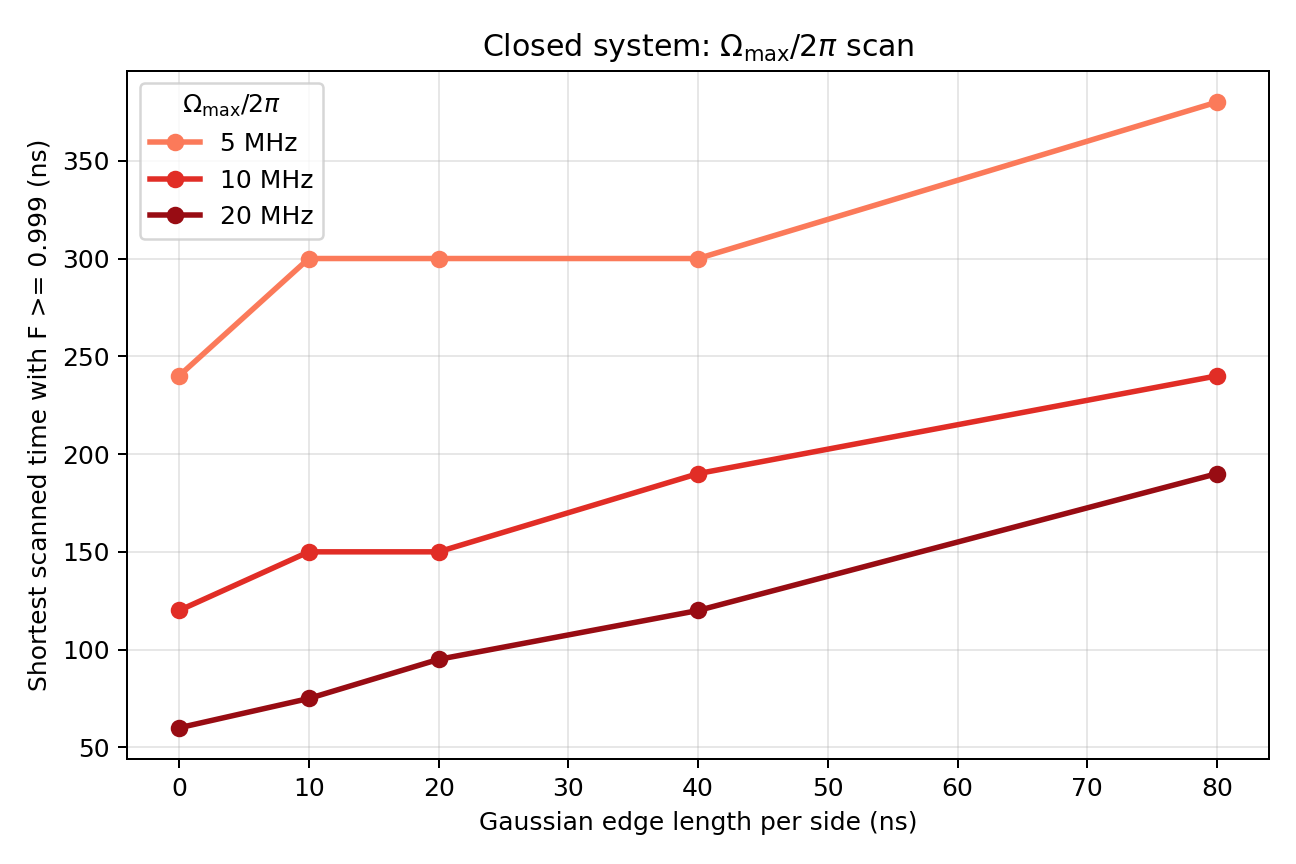

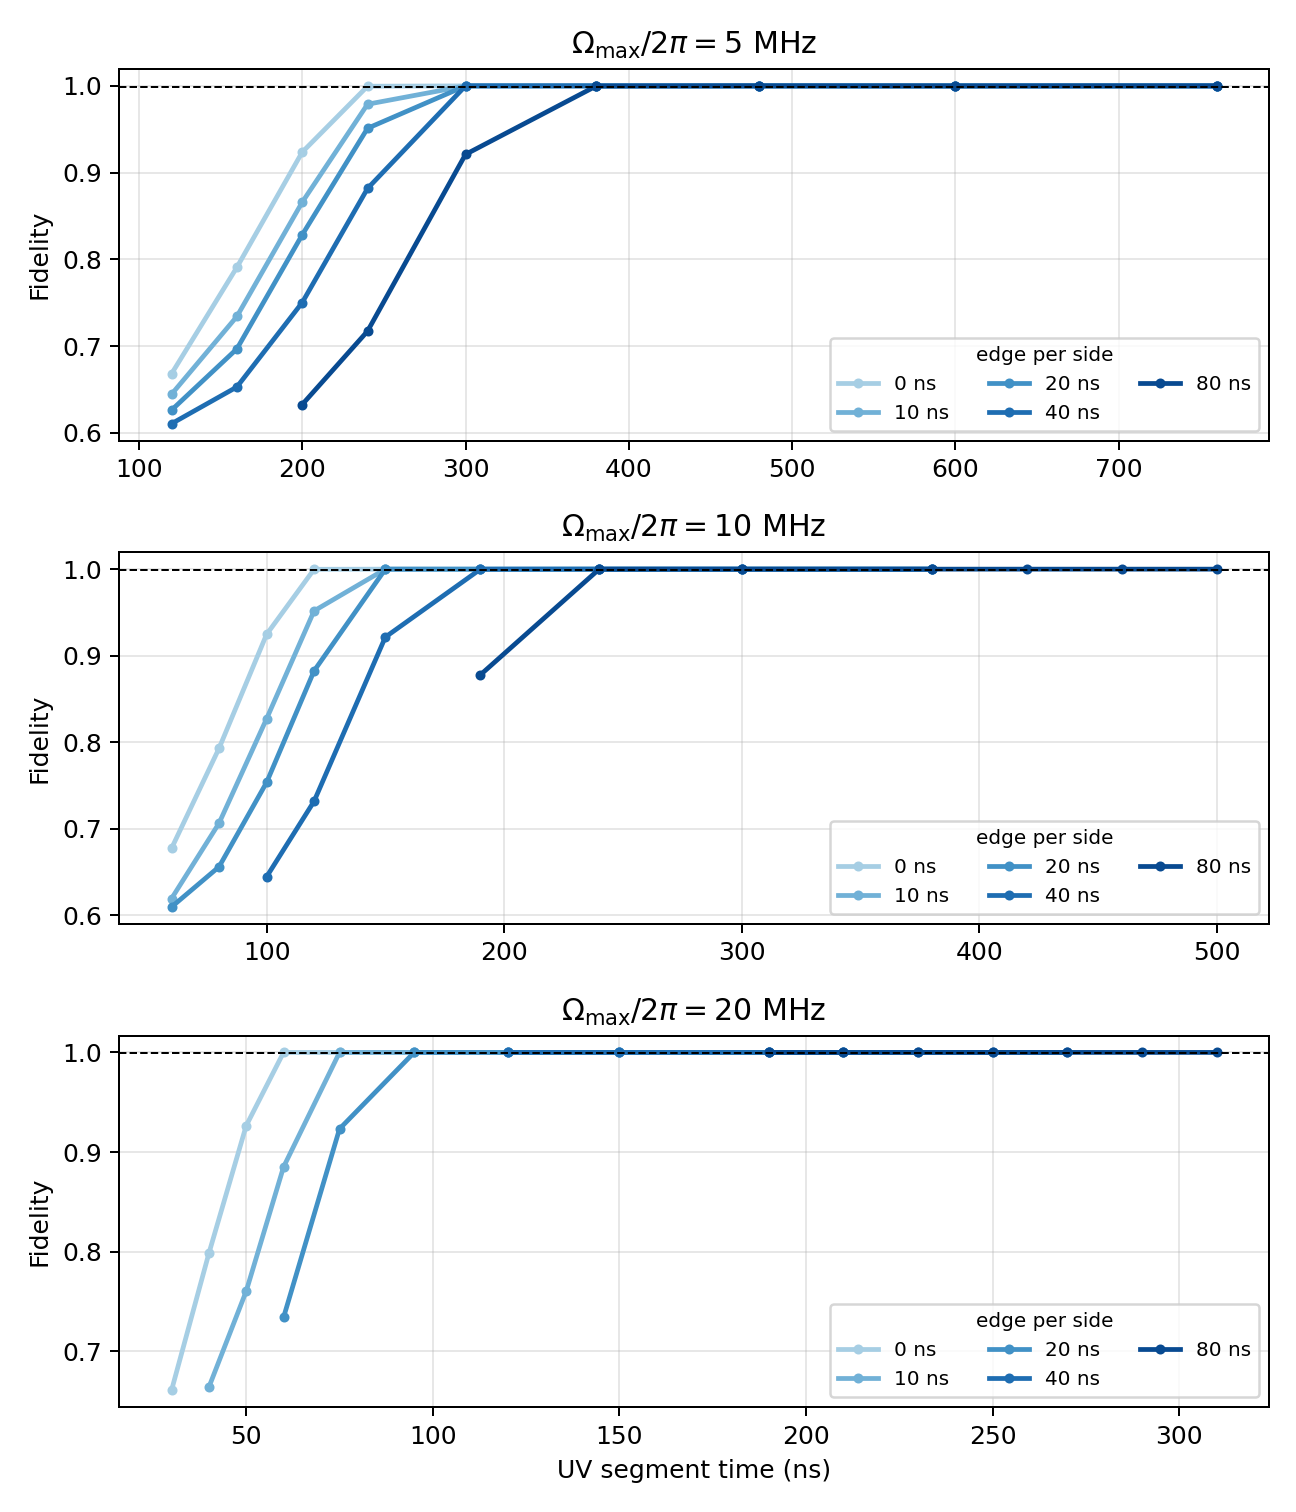

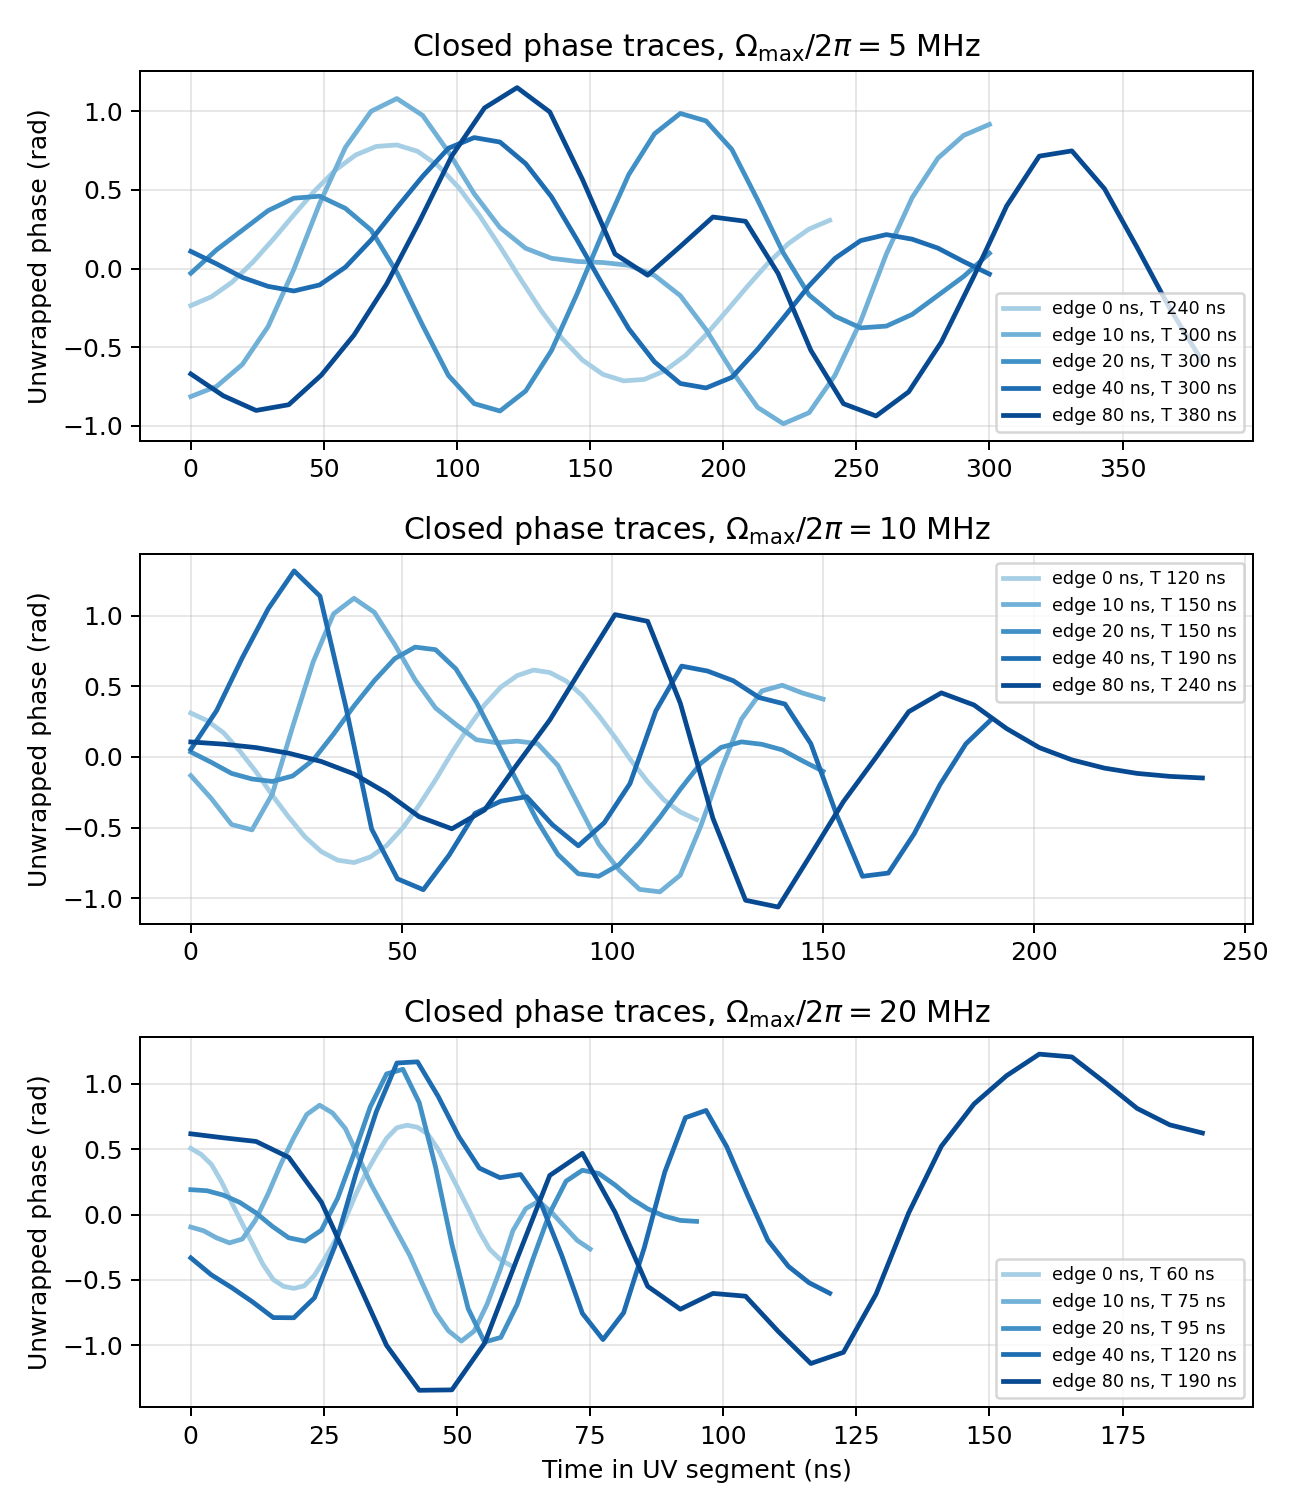

In [9]:
from IPython.display import Image, display

for figure_name in [
    "minimum_time_vs_edge.png",
    "fidelity_curves.png",
    "phase_traces_at_threshold.png",
]:
    display(Image(filename=str(output_dir / figure_name)))


## Open-System Rydberg Decay Results

### Open-System Decay Reproduction Code

The following code shows how the final noisy branch is generated from the closed-system first-threshold pulses. It keeps direct time-slot phase variables, adds the Rydberg decay no-jump term, reoptimizes at the same total times, and saves the decay figures.

In [ ]:
class RydbergDecayShelvedCRPhaseGRAPE(ClosedShelvedCRPhaseGRAPE):
    """Same direct phase controls, with Rydberg decay as a no-jump non-Hermitian term."""

    def __init__(
        self,
        omega_max_mhz: float,
        total_time_ns: float,
        edge_time_ns: float,
        *,
        num_tslots: int = 64,
        rydberg_lifetime_s: float = 65e-6,
        blockade_shift_mhz: float = 160.0,
        smoothness_weight: float = 1e-4,
        curvature_weight: float = 1e-4,
    ) -> None:
        super().__init__(
            omega_max_mhz,
            total_time_ns,
            edge_time_ns,
            num_tslots=num_tslots,
            blockade_shift_mhz=blockade_shift_mhz,
            smoothness_weight=smoothness_weight,
            curvature_weight=curvature_weight,
        )
        self.rydberg_lifetime_s = float(rydberg_lifetime_s)
        self.decay_rate_over_omega = 1.0 / (2.0 * np.pi * self.omega_max_mhz * 1e6 * self.rydberg_lifetime_s)
        self.g_decay = -0.5 * np.diag(
            [0.0, 0.0, self.decay_rate_over_omega, 0.0, self.decay_rate_over_omega, 2.0 * self.decay_rate_over_omega]
        ).astype(np.complex128)

    def generator(self, amplitude: float, phase: float) -> np.ndarray:
        return (
            self.g_d
            + self.g_decay
            + float(amplitude) * (math.cos(float(phase)) * self.g_x + math.sin(float(phase)) * self.g_y)
        )

    def evaluate(self, variables: np.ndarray) -> dict[str, object]:
        phases = wrap_phase(variables[: self.num_tslots])
        alpha = float(variables[-2])
        beta = float(variables[-1])
        unitary = np.eye(6, dtype=np.complex128)
        for amplitude, phase in zip(self.envelope, phases):
            unitary = expm(self.dt * self.generator(float(amplitude), float(phase))) @ unitary
        z_diag = np.diag(unitary)[self.computational_indices]
        process_fidelity, active_population, no_jump_average_fidelity = self._no_jump_process_metrics_from_z(
            z_diag,
            alpha,
            beta,
        )
        return {
            # Final optimized/reporting fidelity for the noisy dense scan:
            # process fidelity of the no-jump Kraus operator restricted to the 4D computational subspace.
            "fidelity": process_fidelity,
            "process_fidelity": process_fidelity,
            "no_jump_average_fidelity": no_jump_average_fidelity,
            "active_population": active_population,
            "loss_proxy": float(1.0 - active_population),
            "z_diag": [complex(value) for value in z_diag],
            "phases": phases,
            "alpha": alpha,
            "beta": beta,
            "envelope": self.envelope,
        }

    def _no_jump_process_metrics_from_z(
        self,
        z_diag: np.ndarray,
        alpha: float,
        beta: float,
    ) -> tuple[float, float, float]:
        """Return process fidelity, active population, and old no-jump average-fidelity proxy.

        The no-jump evolution is a single trace-decreasing Kraus operator K.
        In the full 4D computational basis, the restricted block is diagonal with entries
        (z_00, z_0c, z_c0, z_cc) = (z_0, z_1, z_1, z_3). Therefore

            F_pro = |Tr(D_CZ^dagger K_comp)|^2 / 4^2

        is exactly the weighted overlap below. The active population remains only a diagnostic.
        """
        target = self.target_phases(alpha, beta)
        overlap = np.sum(self.weights * np.conj(target) * z_diag)
        process_fidelity = float(abs(overlap) ** 2 / 16.0)
        active_population = float(np.sum(self.weights * np.abs(z_diag) ** 2) / 4.0)
        no_jump_average_fidelity = float((4.0 * process_fidelity + active_population) / 5.0)
        return process_fidelity, active_population, no_jump_average_fidelity

    def objective_and_gradient(self, variables: np.ndarray) -> tuple[float, np.ndarray]:
        phases = wrap_phase(variables[: self.num_tslots])
        alpha = float(variables[-2])
        beta = float(variables[-1])
        propagators: list[np.ndarray] = []
        prefixes: list[np.ndarray] = [np.eye(6, dtype=np.complex128)]
        current = prefixes[0]
        for amplitude, phase in zip(self.envelope, phases):
            generator = self.generator(float(amplitude), float(phase))
            propagator = expm(self.dt * generator)
            propagators.append(propagator)
            current = propagator @ current
            prefixes.append(current)

        z_diag = np.diag(current)[self.computational_indices]
        target = self.target_phases(alpha, beta)
        conjugate_target = np.conj(target)
        overlap = np.sum(self.weights * conjugate_target * z_diag)
        # True process fidelity of the no-jump Kraus operator K_comp against the CZ target.
        # The reduced-basis weights expand (z_0, z_1, z_3) into the full 4D diagonal
        # (z_00, z_0c, z_c0, z_cc) = (z_0, z_1, z_1, z_3).
        process_fidelity = abs(overlap) ** 2 / 16.0

        gradient = np.zeros_like(variables)
        suffixes: list[np.ndarray] = [np.eye(6, dtype=np.complex128) for _ in range(self.num_tslots)]
        current_suffix = np.eye(6, dtype=np.complex128)
        for index in range(self.num_tslots - 1, -1, -1):
            suffixes[index] = current_suffix
            current_suffix = current_suffix @ propagators[index]

        for index, (amplitude, phase) in enumerate(zip(self.envelope, phases)):
            generator = self.generator(float(amplitude), float(phase))
            d_generator = float(amplitude) * (-math.sin(float(phase)) * self.g_x + math.cos(float(phase)) * self.g_y)
            d_propagator = expm_frechet(self.dt * generator, self.dt * d_generator, compute_expm=False)
            d_unitary = suffixes[index] @ d_propagator @ prefixes[index]
            dz_diag = np.diag(d_unitary)[self.computational_indices]
            d_overlap = np.sum(self.weights * conjugate_target * dz_diag)
            # Analytic gradient: d |S|^2 / 16 = 2 Re[S^* dS] / 16.
            d_process = 2.0 * np.real(np.conj(overlap) * d_overlap) / 16.0
            gradient[index] = -d_process

        for offset, coefficients in enumerate([self.alpha_coefficients, self.beta_coefficients]):
            d_conjugate_target = -1j * coefficients * conjugate_target
            d_overlap = np.sum(self.weights * d_conjugate_target * z_diag)
            d_process = 2.0 * np.real(np.conj(overlap) * d_overlap) / 16.0
            gradient[-2 + offset] = -d_process

        regularization, regularization_gradient = phase_regularization(
            phases,
            self.smoothness_weight,
            self.curvature_weight,
        )
        gradient[: self.num_tslots] += regularization_gradient
        return float(1.0 - process_fidelity + regularization), gradient


def resample_phase_controls(phases: list[float], target_slots: int) -> np.ndarray:
    old_grid = np.linspace(0.0, 1.0, len(phases), endpoint=True)
    new_grid = np.linspace(0.0, 1.0, int(target_slots), endpoint=True)
    return wrap_phase(np.interp(new_grid, old_grid, unwrap_for_plot(phases)))


def run_rydberg_decay_scan(
    *,
    num_tslots: int = 64,
    max_iter: int = 180,
    rydberg_lifetime_s: float = 65e-6,
) -> list[dict[str, object]]:
    closed_data = json.loads((output_dir / "closed_cr_edge_scan_results.json").read_text(encoding="utf-8"))["results"]
    minimum_data = json.loads((output_dir / "closed_cr_edge_scan_min_times.json").read_text(encoding="utf-8"))["summary"]
    results: list[dict[str, object]] = []
    for minimum_row in minimum_data:
        threshold_time = minimum_row["shortest_passing_time_ns"]
        if threshold_time is None:
            continue
        closed_row = next(
            row
            for row in closed_data
            if row["omega_max_mhz"] == minimum_row["omega_max_mhz"]
            and row["edge_ns"] == minimum_row["edge_ns"]
            and row["total_time_ns"] == threshold_time
        )
        grape = RydbergDecayShelvedCRPhaseGRAPE(
            float(closed_row["omega_max_mhz"]),
            float(closed_row["total_time_ns"]),
            float(closed_row["edge_ns"]),
            num_tslots=num_tslots,
            rydberg_lifetime_s=rydberg_lifetime_s,
        )
        initial_phases = resample_phase_controls([float(value) for value in closed_row["phases"]], num_tslots)
        start = np.concatenate(
            [
                initial_phases,
                np.array([float(closed_row["alpha"]), float(closed_row["beta"])], dtype=np.float64),
            ]
        )
        result, evaluated = grape.optimize([start], max_iter=max_iter)
        results.append(
            {
                "omega_max_mhz": float(closed_row["omega_max_mhz"]),
                "edge_ns": float(closed_row["edge_ns"]),
                "total_time_ns": float(closed_row["total_time_ns"]),
                "num_tslots": int(num_tslots),
                "max_iter": int(max_iter),
                "rydberg_lifetime_s": float(rydberg_lifetime_s),
                "rydberg_decay_rate_over_omega": float(grape.decay_rate_over_omega),
                "fidelity": float(evaluated["fidelity"]),
                "process_fidelity": float(evaluated["process_fidelity"]),
                "active_population": float(evaluated["active_population"]),
                "loss_proxy": float(evaluated["loss_proxy"]),
                "success": bool(result.success),
                "num_iter": int(result.nit),
                "alpha": float(evaluated["alpha"]),
                "beta": float(evaluated["beta"]),
                "phases": [float(value) for value in evaluated["phases"]],
            }
        )

    (output_dir / "rydberg_decay_65us_results.json").write_text(
        json.dumps(
            {
                "noise_model": "Rydberg decay as non-Hermitian no-jump term",
                "rydberg_lifetime_s": rydberg_lifetime_s,
                "decay_matrix_diag": [0.0, 0.0, "gamma", 0.0, "gamma", "2 gamma"],
                "results": results,
            },
            indent=2,
        ),
        encoding="utf-8",
    )
    with (output_dir / "rydberg_decay_65us_summary.csv").open("w", newline="", encoding="utf-8") as handle:
        columns = [
            "omega_max_mhz",
            "edge_ns",
            "total_time_ns",
            "fidelity",
            "process_fidelity",
            "active_population",
            "loss_proxy",
            "success",
            "num_iter",
            "rydberg_decay_rate_over_omega",
        ]
        writer = csv.DictWriter(handle, fieldnames=columns)
        writer.writeheader()
        writer.writerows([{column: row[column] for column in columns} for row in results])
    plot_rydberg_decay_fidelity(results)
    plot_rydberg_decay_phase_traces(results)
    return results


def plot_rydberg_decay_fidelity(results: list[dict[str, object]], threshold: float = 0.999) -> None:
    omega_values = sorted({float(row["omega_max_mhz"]) for row in results})
    colors = omega_reds(omega_values)
    plt.figure(figsize=(9.6, 5.4))
    for omega in omega_values:
        rows = sorted([row for row in results if float(row["omega_max_mhz"]) == omega], key=lambda row: float(row["edge_ns"]))
        plt.plot(
            [float(row["edge_ns"]) for row in rows],
            [float(row["fidelity"]) for row in rows],
            marker="o",
            linewidth=2.4,
            markersize=6,
            color=colors[omega],
            label=f"{omega:g} MHz",
        )
    plt.axhline(threshold, color="black", linestyle="--", linewidth=1.1)
    plt.xlabel("Gaussian edge length per side (ns)")
    plt.ylabel("Fidelity with Rydberg decay")
    plt.title(r"Open system with Rydberg decay: $\Omega_{\max}/2\pi$ scan")
    plt.grid(True, alpha=0.35)
    plt.legend(title=r"$\Omega_{\max}/2\pi$")
    plt.tight_layout()
    plt.savefig(output_dir / "rydberg_decay_65us_fidelity.png", dpi=180)
    plt.close()


def plot_rydberg_decay_phase_traces(results: list[dict[str, object]]) -> None:
    omega_values = sorted({float(row["omega_max_mhz"]) for row in results})
    figure, axes = plt.subplots(len(omega_values), 1, figsize=(8.8, 9.0), sharex=False)
    axes_array = np.atleast_1d(axes)
    for axis, omega in zip(np.ravel(axes_array), omega_values):
        rows = sorted([row for row in results if float(row["omega_max_mhz"]) == omega], key=lambda row: float(row["edge_ns"]))
        colors = edge_blues([float(row["edge_ns"]) for row in rows])
        for row in rows:
            phases = [float(value) for value in row["phases"]]
            times = np.linspace(0.0, float(row["total_time_ns"]), len(phases))
            edge = float(row["edge_ns"])
            axis.plot(
                times,
                unwrap_for_plot(phases),
                linewidth=1.8,
                color=colors[edge],
                label=f"edge {edge:g} ns, T {float(row['total_time_ns']):g} ns",
            )
        axis.set_title(rf"Decay-optimized phase traces, $\Omega_{{\max}}/2\pi={omega:g}\,\mathrm{{MHz}}$")
        axis.set_ylabel("Unwrapped phase (rad)")
        axis.grid(True, alpha=0.3)
        axis.legend(fontsize=7)
    axes_array[-1].set_xlabel("Time in UV segment (ns)")
    figure.tight_layout()
    figure.savefig(output_dir / "rydberg_decay_65us_phase_traces_at_threshold_times.png", dpi=180)
    plt.close(figure)


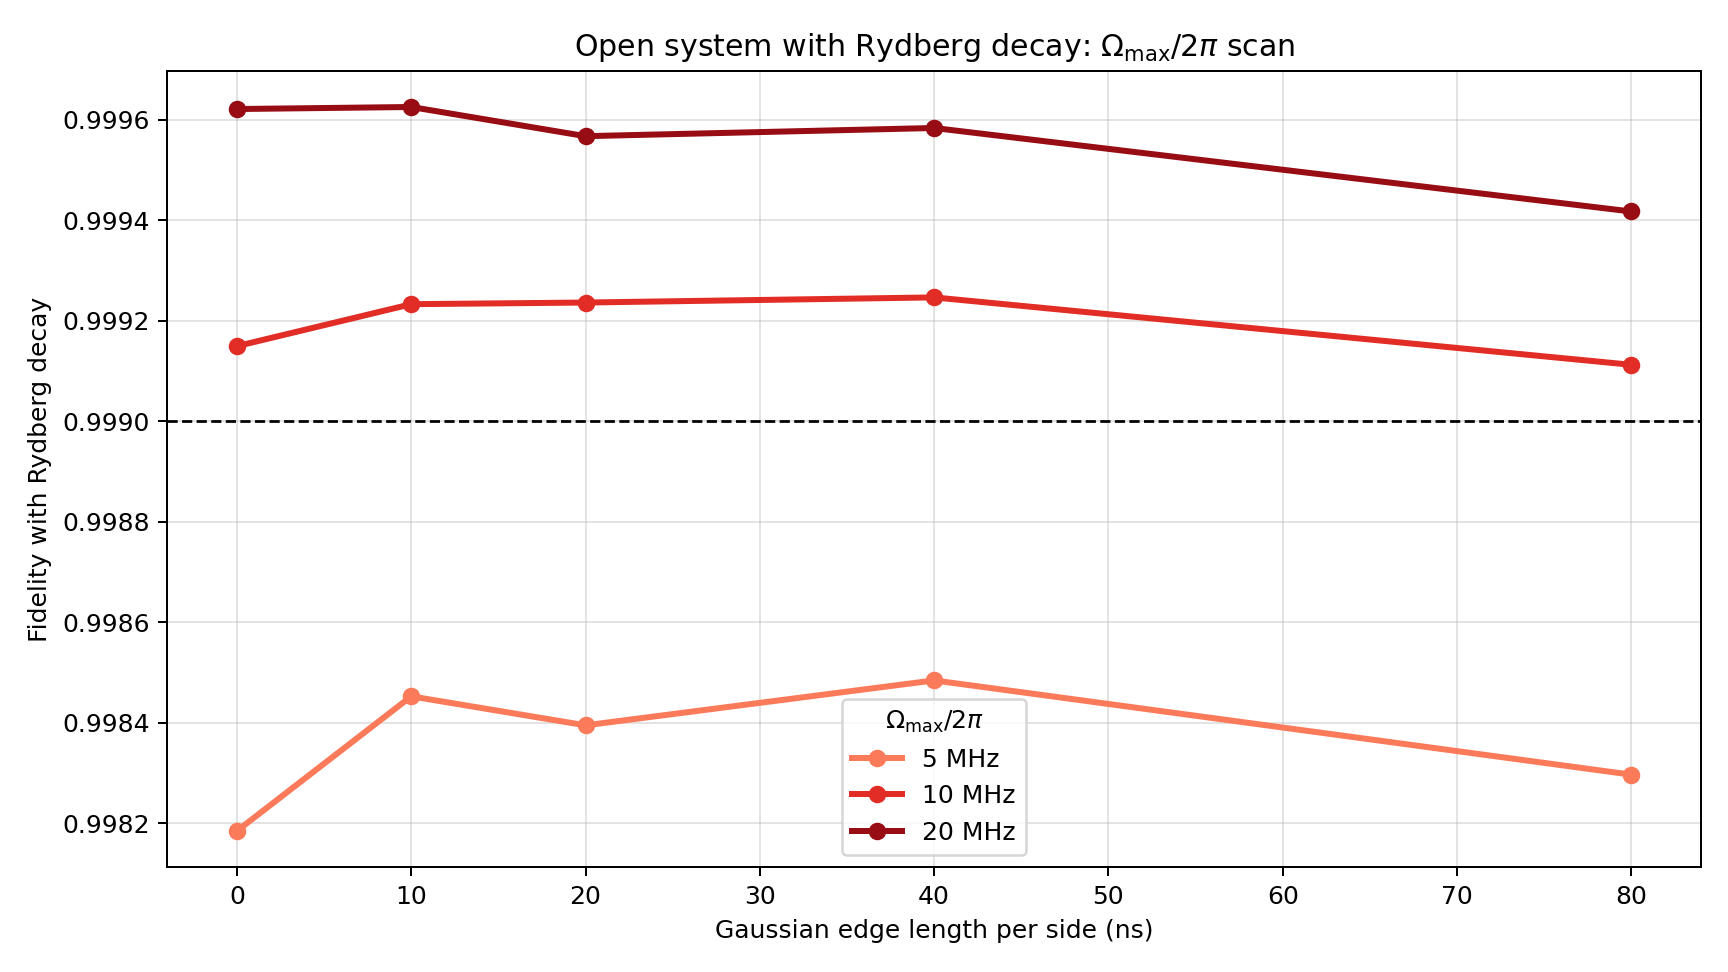

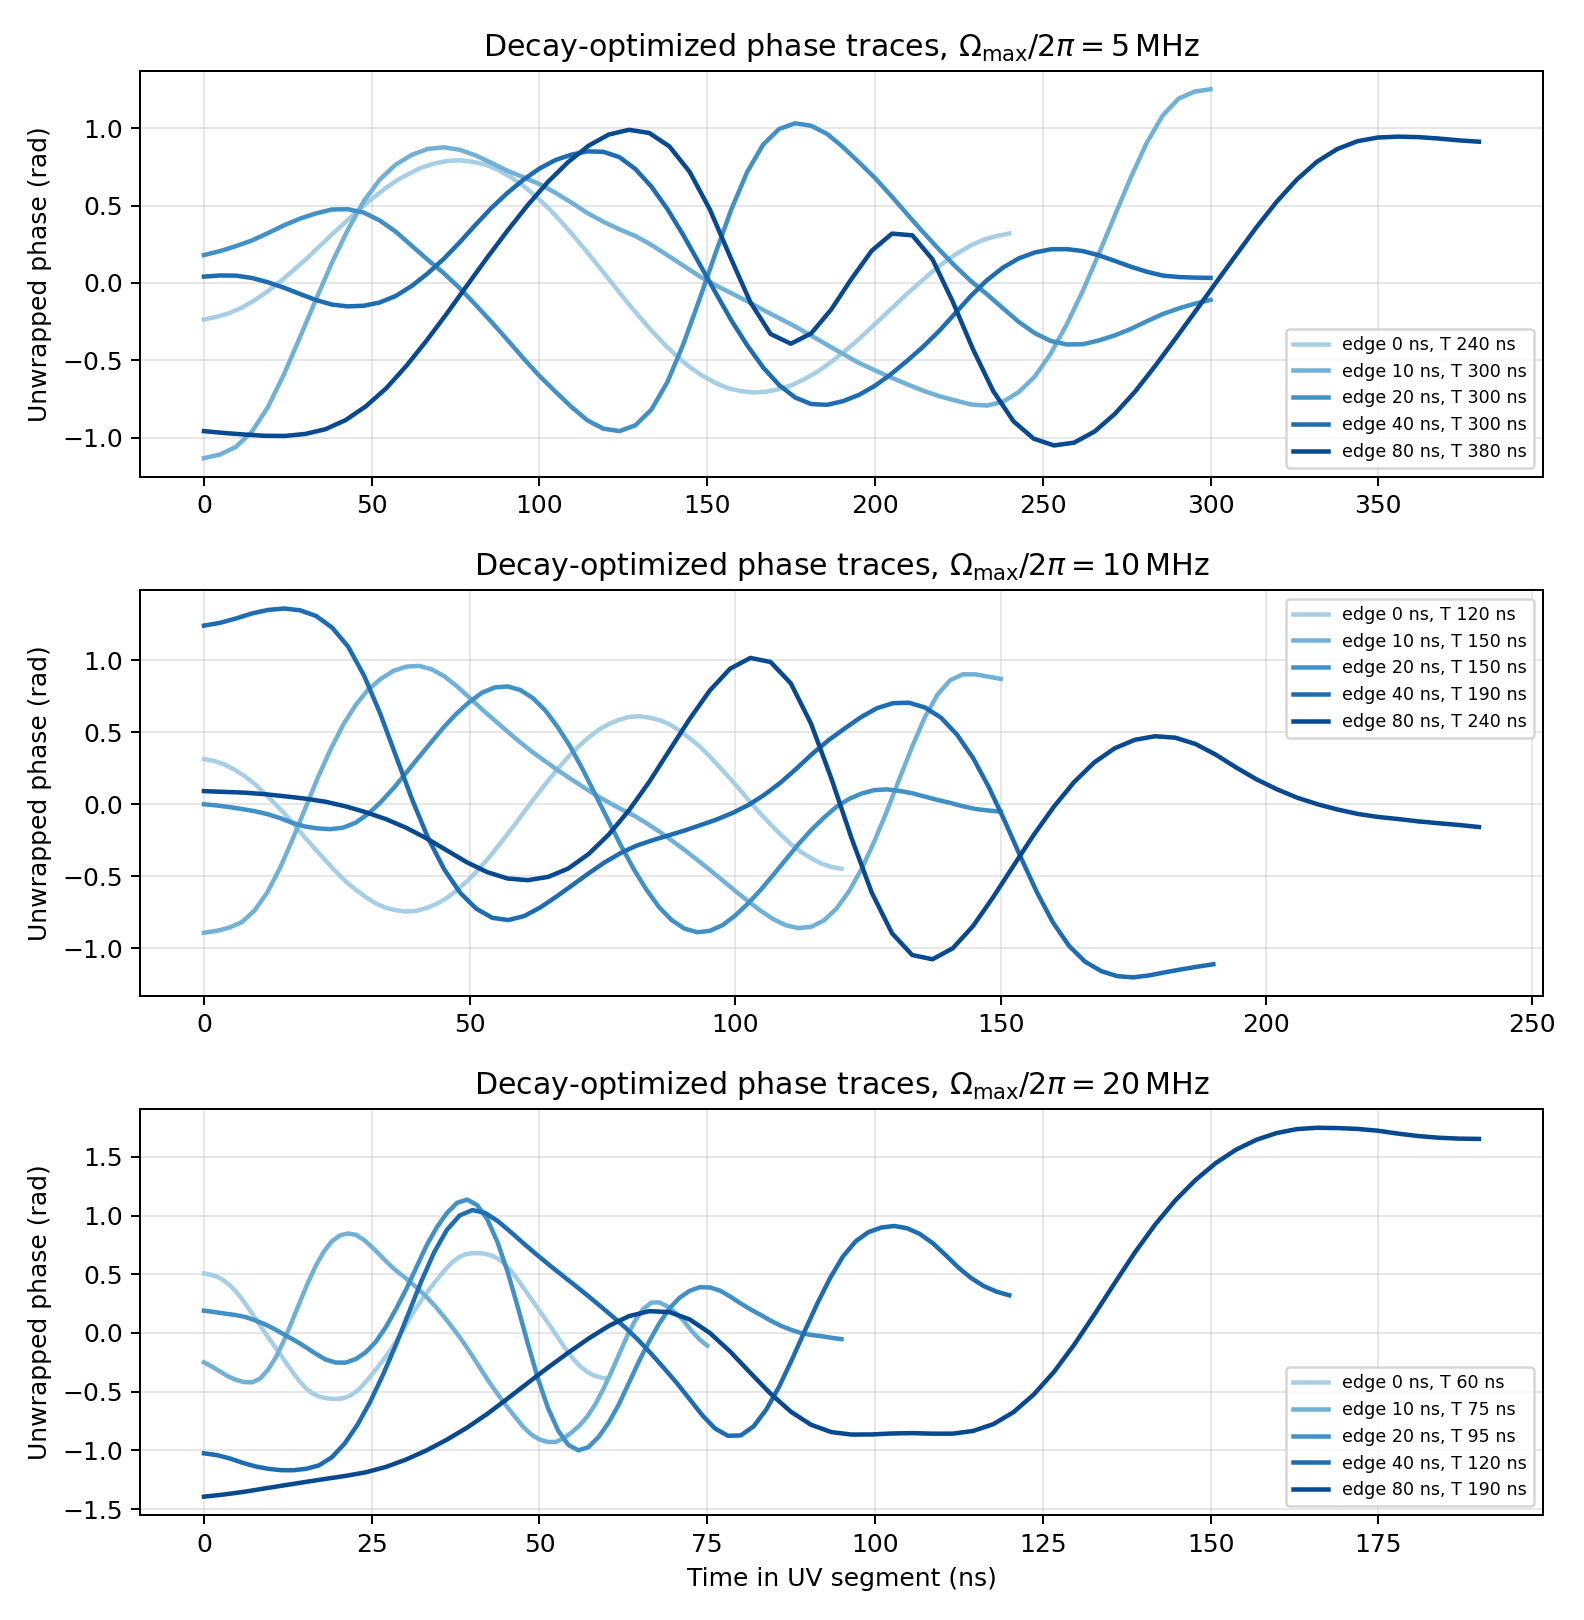

In [ ]:
from IPython.display import Image, display

for figure_name in [
    "rydberg_decay_65us_fidelity.png",
    "rydberg_decay_65us_phase_traces_at_threshold_times.png",
]:
    display(Image(filename=str(output_dir / figure_name)))


### Dense Noisy Time Scan

为区分 Gaussian edge length 对 noisy UV 段所需总时间的影响，这里额外保存带 Rydberg decay 的 dense time scan。当前版本保留 no-jump non-Hermitian 演化，但把优化目标和最终 `fidelity` 改为 no-jump Kraus operator 在 4D computational subspace 上相对于 CZ target 的真正 process fidelity：

$$
F_{\mathrm{pro}}=\frac{|\mathrm{Tr}(D_{\mathrm{CZ}}^\dagger K_{\mathrm{comp}})|^2}{4^2}.
$$

`active_population`、`loss_proxy=1-active_population` 和旧的 `(4 F_pro + active_population)/5` 形式仍作为诊断量保存，但不再用于通过阈值或优化。加密窗口包括 `240-380 ns`、`300-380 ns` 和 `150-190 ns`。优化为 direct time-slot phase control，显式使用 smoothness/curvature regularization，不使用基函数。当前 dense artifact 已经用该定义重新优化并覆盖旧结果；若需要从头复现，将下面代码中的 FORCE_RECOMPUTE_NOISY_DENSE_SCAN 改为 True。


In [ ]:
# Dense noisy time scan configuration used for the current artifact.
# The actual saved results are loaded below; rerunning this cell is not required for review.

NOISY_DENSE_TIME_GRIDS_NS = {
    5.0: [240, 260, 280, 300, 320, 340, 360, 380],
    10.0: [120, 135, 150, 160, 170, 180, 190, 210, 240],
    20.0: [60, 75, 90, 105, 120, 135, 150, 160, 170, 180, 190],
}

dense_scan_path = output_dir / "rydberg_decay_65us_dense_time_scan_results.json"
dense_min_time_path = output_dir / "rydberg_decay_65us_dense_min_times.json"
dense_scan_path, dense_min_time_path


#### Reproducible dense noisy scan generator

The following cell is the complete program used to generate the final dense noisy scan artifacts.  It is kept in the notebook so that the notebook can stand alone: if the dense JSON files are missing, or if `FORCE_RECOMPUTE_NOISY_DENSE_SCAN` is set to `True`, running the notebook will recompute every `(Omega_max, edge, T)` point, write the JSON/CSV summaries, and regenerate the three dense-scan figures.

For normal review, the flag is left `False` so that existing artifacts are loaded instead of rerunning the expensive optimization.  The explicit regularization weights are stored in the artifact metadata and in each row.


In [31]:
# Complete generator for the final dense noisy scan.
import csv
import json
import time
import numpy as np
import matplotlib.pyplot as plt

# It is intentionally self-contained relative to the model/optimizer cells above:
# run the notebook from the top, then this cell can regenerate the final dense artifacts.

NOISY_DENSE_EDGE_VALUES_NS = [0.0, 10.0, 20.0, 40.0, 80.0]
NOISY_DENSE_THRESHOLD = 0.999
NOISY_DENSE_NUM_TSLOTS = 64
NOISY_DENSE_MAX_ITER = 360
NOISY_DENSE_SMOOTHNESS_WEIGHT = 1e-4
NOISY_DENSE_CURVATURE_WEIGHT = 1e-4
NOISY_DENSE_RYDBERG_LIFETIME_S = 65e-6

# Recompute is expensive because it optimizes 123 GRAPE problems.
# Existing dense artifacts have been regenerated with process-fidelity results.
# Leave False for review; set True to reproduce the optimization from scratch.
FORCE_RECOMPUTE_NOISY_DENSE_SCAN = False
FORCE_REPLOT_NOISY_DENSE_FIGURES = False

dense_selected_phase_path = output_dir / "rydberg_decay_65us_dense_selected_phase_rows.json"
dense_time_scan_csv_path = output_dir / "rydberg_decay_65us_dense_time_scan_summary.csv"
dense_summary_csv_path = output_dir / "rydberg_decay_65us_dense_min_times.csv"
dense_figure_paths = [
    output_dir / "rydberg_decay_65us_dense_fidelity_curves.png",
    output_dir / "rydberg_decay_65us_dense_best_fidelity_vs_edge.png",
    output_dir / "rydberg_decay_65us_dense_selected_time_vs_edge.png",
    output_dir / "rydberg_decay_65us_dense_selected_phase_traces.png",
]


def noisy_dense_config_metadata() -> dict[str, object]:
    """Return the exact scalar configuration used by the final dense scan."""
    return {
        "threshold": float(NOISY_DENSE_THRESHOLD),
        "noise_model": "Rydberg decay as non-Hermitian no-jump term",
        "fidelity_definition": "no-jump Kraus process fidelity |Tr(D_CZ^dagger K_comp)|^2 / 16",
        "rydberg_lifetime_s": float(NOISY_DENSE_RYDBERG_LIFETIME_S),
        "uses_basis_functions": False,
        "uses_regularization": True,
        "regularization_model": "wrapped first- and second-difference phase penalty",
        "smoothness_weight": float(NOISY_DENSE_SMOOTHNESS_WEIGHT),
        "curvature_weight": float(NOISY_DENSE_CURVATURE_WEIGHT),
        "num_tslots": int(NOISY_DENSE_NUM_TSLOTS),
        "max_iter": int(NOISY_DENSE_MAX_ITER),
        "time_grid_note": "Dense windows include 240-380 ns, 300-380 ns, and 150-190 ns.",
    }


def dense_time_is_allowed(total_time_ns: float, edge_ns: float) -> bool:
    """Skip unphysical points whose UV window is shorter than two Gaussian edges plus a small plateau."""
    return float(total_time_ns) + 1e-9 >= 2.0 * float(edge_ns) + 20.0


def noisy_dense_initial_starts(
    grape: RydbergDecayShelvedCRPhaseGRAPE,
    previous_variables: np.ndarray | None,
    omega_max_mhz: float,
    edge_ns: float,
    time_index: int,
) -> list[np.ndarray]:
    """Build deterministic starts: continuation in T plus two seeded smooth random phase guesses."""
    starts: list[np.ndarray] = []
    if previous_variables is not None and previous_variables.size == grape.num_tslots + 2:
        starts.append(np.asarray(previous_variables, dtype=np.float64))

    # The seeds are deterministic so that a full rerun is reproducible.
    seed_base = int(1000 * omega_max_mhz + 10 * edge_ns + time_index)
    starts.append(grape.initial_guess(71000 + seed_base))
    starts.append(grape.initial_guess(93000 + seed_base))
    return starts


def run_noisy_dense_time_scan() -> list[dict[str, object]]:
    """Optimize every dense noisy scan point and return row dictionaries for JSON/CSV output."""
    output_dir.mkdir(parents=True, exist_ok=True)
    rows: list[dict[str, object]] = []
    started = time.perf_counter()

    for omega, time_grid in sorted(NOISY_DENSE_TIME_GRIDS_NS.items()):
        for edge in NOISY_DENSE_EDGE_VALUES_NS:
            previous_variables: np.ndarray | None = None
            for time_index, total_time in enumerate(sorted(float(value) for value in time_grid)):
                if not dense_time_is_allowed(total_time, edge):
                    continue

                grape = RydbergDecayShelvedCRPhaseGRAPE(
                    float(omega),
                    float(total_time),
                    float(edge),
                    num_tslots=NOISY_DENSE_NUM_TSLOTS,
                    rydberg_lifetime_s=NOISY_DENSE_RYDBERG_LIFETIME_S,
                    smoothness_weight=NOISY_DENSE_SMOOTHNESS_WEIGHT,
                    curvature_weight=NOISY_DENSE_CURVATURE_WEIGHT,
                )
                starts = noisy_dense_initial_starts(grape, previous_variables, omega, edge, time_index)
                result, evaluated = grape.optimize(starts, max_iter=NOISY_DENSE_MAX_ITER)
                previous_variables = np.asarray(result.x, dtype=np.float64).copy()

                row = {
                    "omega_max_mhz": float(omega),
                    "edge_ns": float(edge),
                    "total_time_ns": float(total_time),
                    "num_tslots": int(NOISY_DENSE_NUM_TSLOTS),
                    "max_iter": int(NOISY_DENSE_MAX_ITER),
                    "smoothness_weight": float(NOISY_DENSE_SMOOTHNESS_WEIGHT),
                    "curvature_weight": float(NOISY_DENSE_CURVATURE_WEIGHT),
                    "rydberg_lifetime_s": float(NOISY_DENSE_RYDBERG_LIFETIME_S),
                    "fidelity": float(evaluated["fidelity"]),
                    "process_fidelity": float(evaluated["process_fidelity"]),
                    "no_jump_average_fidelity": float(evaluated["no_jump_average_fidelity"]),
                    "active_population": float(evaluated["active_population"]),
                    "loss_proxy": float(evaluated["loss_proxy"]),
                    "passed": bool(float(evaluated["fidelity"]) >= NOISY_DENSE_THRESHOLD),
                    "success": bool(result.success),
                    "num_iter": int(result.nit),
                    "alpha": float(evaluated["alpha"]),
                    "beta": float(evaluated["beta"]),
                    "phases": [float(value) for value in evaluated["phases"]],
                }
                rows.append(row)
                print(
                    f"Omega/2pi={omega:4.0f} MHz edge={edge:5.0f} ns T={total_time:6.0f} ns "
                    f"F={row['fidelity']:.9f} success={row['success']}",
                    flush=True,
                )

    print(f"Dense noisy scan completed: {len(rows)} points in {time.perf_counter() - started:.1f} s")
    return rows


def summarize_noisy_dense_rows(
    rows: list[dict[str, object]],
) -> tuple[list[dict[str, object]], list[dict[str, object]]]:
    """Return threshold/best-time summary and selected phase rows for plotting."""
    summary: list[dict[str, object]] = []
    selected_rows: list[dict[str, object]] = []

    for omega in sorted({float(row["omega_max_mhz"]) for row in rows}):
        for edge in sorted({float(row["edge_ns"]) for row in rows if float(row["omega_max_mhz"]) == omega}):
            group = sorted(
                [row for row in rows if float(row["omega_max_mhz"]) == omega and float(row["edge_ns"]) == edge],
                key=lambda row: float(row["total_time_ns"]),
            )
            if not group:
                continue
            passed = [row for row in group if bool(row["passed"])]
            best = max(group, key=lambda row: float(row["fidelity"]))
            selected = dict(passed[0] if passed else best)
            selected["selection_kind"] = "first above threshold" if passed else "best below threshold"
            selected["shortest_passing_time_ns"] = None if not passed else float(passed[0]["total_time_ns"])
            selected["best_time_ns"] = float(best["total_time_ns"])
            selected["best_fidelity"] = float(best["fidelity"])
            selected_rows.append(selected)

            summary.append(
                {
                    "omega_max_mhz": float(omega),
                    "edge_ns": float(edge),
                    "shortest_passing_time_ns": None if not passed else float(passed[0]["total_time_ns"]),
                    "first_passing_fidelity": None if not passed else float(passed[0]["fidelity"]),
                    "best_time_ns": float(best["total_time_ns"]),
                    "best_fidelity": float(best["fidelity"]),
                    "scanned_times_ns": [float(row["total_time_ns"]) for row in group],
                }
            )
    return summary, selected_rows


def write_noisy_dense_artifacts(
    rows: list[dict[str, object]],
    summary: list[dict[str, object]],
    selected_rows: list[dict[str, object]],
) -> None:
    """Write machine-readable JSON/CSV artifacts for the dense noisy scan."""
    metadata = noisy_dense_config_metadata()
    dense_scan_path.write_text(json.dumps({**metadata, "results": rows}, indent=2), encoding="utf-8")
    dense_min_time_path.write_text(json.dumps({**metadata, "summary": summary}, indent=2), encoding="utf-8")
    dense_selected_phase_path.write_text(json.dumps({**metadata, "rows": selected_rows}, indent=2), encoding="utf-8")

    result_columns = [
        "omega_max_mhz",
        "edge_ns",
        "total_time_ns",
        "num_tslots",
        "max_iter",
        "smoothness_weight",
        "curvature_weight",
        "fidelity",
        "process_fidelity",
        "no_jump_average_fidelity",
        "active_population",
        "loss_proxy",
        "passed",
        "success",
        "num_iter",
        "alpha",
        "beta",
    ]
    with dense_time_scan_csv_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=result_columns)
        writer.writeheader()
        writer.writerows([{column: row.get(column) for column in result_columns} for row in rows])

    summary_columns = [
        "omega_max_mhz",
        "edge_ns",
        "shortest_passing_time_ns",
        "first_passing_fidelity",
        "best_time_ns",
        "best_fidelity",
        "scanned_times_ns",
    ]
    with dense_summary_csv_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=summary_columns)
        writer.writeheader()
        writer.writerows([{column: row.get(column) for column in summary_columns} for row in summary])


def tag_loaded_noisy_dense_metadata(payload: dict[str, object], row_key: str) -> bool:
    """Backfill explicit regularization metadata into existing artifacts without changing numerical results."""
    changed = False
    metadata = noisy_dense_config_metadata()
    for key, value in metadata.items():
        if payload.get(key) != value:
            payload[key] = value
            changed = True
    for row in payload.get(row_key, []):
        for key in ["num_tslots", "max_iter", "smoothness_weight", "curvature_weight", "rydberg_lifetime_s"]:
            if row.get(key) != metadata[key]:
                row[key] = metadata[key]
                changed = True
    return changed


def load_noisy_dense_artifacts() -> tuple[list[dict[str, object]], list[dict[str, object]], list[dict[str, object]]]:
    """Load existing dense artifacts and ensure their metadata records the explicit regularization weights."""
    dense_payload = json.loads(dense_scan_path.read_text(encoding="utf-8"))
    min_payload = json.loads(dense_min_time_path.read_text(encoding="utf-8"))
    selected_payload = json.loads(dense_selected_phase_path.read_text(encoding="utf-8"))

    changed = tag_loaded_noisy_dense_metadata(dense_payload, "results")
    changed = tag_loaded_noisy_dense_metadata(min_payload, "summary") or changed
    changed = tag_loaded_noisy_dense_metadata(selected_payload, "rows") or changed
    if changed:
        dense_scan_path.write_text(json.dumps(dense_payload, indent=2), encoding="utf-8")
        dense_min_time_path.write_text(json.dumps(min_payload, indent=2), encoding="utf-8")
        dense_selected_phase_path.write_text(json.dumps(selected_payload, indent=2), encoding="utf-8")

    return dense_payload["results"], min_payload["summary"], selected_payload["rows"]


def noisy_dense_edge_blues(edge_values: list[float]) -> dict[float, tuple[float, float, float, float]]:
    """Use one blue color ramp for curves whose labels differ by edge length."""
    unique_edges = sorted({float(value) for value in edge_values})
    color_values = np.linspace(0.35, 0.90, len(unique_edges))
    return {edge: plt.cm.Blues(value) for edge, value in zip(unique_edges, color_values)}


def noisy_dense_omega_reds(omega_values: list[float]) -> dict[float, tuple[float, float, float, float]]:
    """Use one red color ramp for curves whose labels differ by Omega_max/2pi."""
    unique_omegas = sorted({float(value) for value in omega_values})
    color_values = np.linspace(0.35, 0.90, len(unique_omegas))
    return {omega: plt.cm.Reds(value) for omega, value in zip(unique_omegas, color_values)}


def plot_noisy_dense_fidelity_curves(rows: list[dict[str, object]]) -> None:
    """Plot fidelity versus scanned UV duration for each Omega_max branch."""
    omega_values = sorted({float(row["omega_max_mhz"]) for row in rows})
    figure, axes = plt.subplots(len(omega_values), 1, figsize=(9.5, 8.8), sharex=False)
    axes_array = np.atleast_1d(axes)
    for axis, omega in zip(axes_array, omega_values):
        omega_rows = [row for row in rows if float(row["omega_max_mhz"]) == omega]
        colors = noisy_dense_edge_blues([float(row["edge_ns"]) for row in omega_rows])
        for edge in sorted(colors):
            edge_rows = sorted(
                [row for row in omega_rows if float(row["edge_ns"]) == edge],
                key=lambda row: float(row["total_time_ns"]),
            )
            axis.plot(
                [float(row["total_time_ns"]) for row in edge_rows],
                [float(row["fidelity"]) for row in edge_rows],
                marker="o",
                linewidth=1.8,
                markersize=4.0,
                color=colors[edge],
                label=f"edge {edge:g} ns",
            )
        axis.axhline(NOISY_DENSE_THRESHOLD, color="black", linestyle="--", linewidth=1.0)
        axis.set_title(rf"Noisy dense time scan, $\Omega_{{\max}}/2\pi={omega:g}$ MHz")
        axis.set_ylabel("No-jump process fidelity")
        axis.grid(True, alpha=0.30)
        axis.legend(ncol=3, fontsize=8)
    axes_array[-1].set_xlabel("UV segment time T (ns)")
    figure.tight_layout()
    figure.savefig(output_dir / "rydberg_decay_65us_dense_fidelity_curves.png", dpi=180)
    plt.close(figure)


def plot_noisy_dense_best_fidelity_vs_edge(summary: list[dict[str, object]]) -> None:
    """Plot the best scanned fidelity against edge length, with the threshold line."""
    omega_values = sorted({float(row["omega_max_mhz"]) for row in summary})
    colors = noisy_dense_omega_reds(omega_values)
    figure, axis = plt.subplots(figsize=(9.8, 5.2))
    for omega in omega_values:
        omega_rows = sorted(
            [row for row in summary if float(row["omega_max_mhz"]) == omega],
            key=lambda row: float(row["edge_ns"]),
        )
        axis.plot(
            [float(row["edge_ns"]) for row in omega_rows],
            [float(row["best_fidelity"]) for row in omega_rows],
            marker="o",
            linewidth=2.0,
            markersize=5.0,
            color=colors[omega],
            label=f"{omega:g} MHz",
        )
    axis.axhline(NOISY_DENSE_THRESHOLD, color="black", linestyle="--", linewidth=1.0, label="threshold 0.999")
    axis.set_xlabel("Gaussian edge length per side (ns)")
    axis.set_ylabel("Best no-jump process fidelity")
    axis.set_title("Noisy dense scan: best process fidelity vs Gaussian edge length")
    axis.grid(True, alpha=0.30)
    axis.legend(title=r"$\Omega_{\max}/2\pi$")
    figure.tight_layout()
    figure.savefig(output_dir / "rydberg_decay_65us_dense_best_fidelity_vs_edge.png", dpi=180)
    plt.close(figure)

def plot_noisy_dense_selected_time_vs_edge(summary: list[dict[str, object]]) -> None:
    """Plot selected time: first passing time, or best below threshold if no point passes."""
    omega_values = sorted({float(row["omega_max_mhz"]) for row in summary})
    colors = noisy_dense_omega_reds(omega_values)
    figure, axis = plt.subplots(figsize=(9.8, 5.2))
    for omega in omega_values:
        omega_rows = sorted(
            [row for row in summary if float(row["omega_max_mhz"]) == omega],
            key=lambda row: float(row["edge_ns"]),
        )
        selected_times = [
            float(row["shortest_passing_time_ns"])
            if row["shortest_passing_time_ns"] is not None
            else float(row["best_time_ns"])
            for row in omega_rows
        ]
        axis.plot(
            [float(row["edge_ns"]) for row in omega_rows],
            selected_times,
            marker="o",
            linewidth=2.0,
            markersize=5.0,
            color=colors[omega],
            label=f"{omega:g} MHz",
        )
        for row, selected_time in zip(omega_rows, selected_times):
            if row["shortest_passing_time_ns"] is None:
                axis.scatter(
                    [float(row["edge_ns"])],
                    [selected_time],
                    marker="x",
                    s=70,
                    color=colors[omega],
                    linewidths=2.0,
                )
    axis.set_xlabel("Gaussian edge length per side (ns)")
    axis.set_ylabel("Selected UV segment time T (ns)")
    axis.set_title("Noisy dense scan: selected time vs Gaussian edge length")
    axis.grid(True, alpha=0.30)
    axis.legend(title=r"$\Omega_{\max}/2\pi$")
    figure.tight_layout()
    figure.savefig(output_dir / "rydberg_decay_65us_dense_selected_time_vs_edge.png", dpi=180)
    plt.close(figure)



def plot_noisy_dense_selected_phase_traces(selected_rows: list[dict[str, object]]) -> None:
    """Plot the phase sequence selected for each edge: first threshold crossing or best below threshold."""
    omega_values = sorted({float(row["omega_max_mhz"]) for row in selected_rows})
    figure, axes = plt.subplots(len(omega_values), 1, figsize=(8.8, 9.0), sharex=False)
    axes_array = np.atleast_1d(axes)
    for axis, omega in zip(axes_array, omega_values):
        omega_rows = sorted(
            [row for row in selected_rows if float(row["omega_max_mhz"]) == omega],
            key=lambda row: float(row["edge_ns"]),
        )
        colors = noisy_dense_edge_blues([float(row["edge_ns"]) for row in omega_rows])
        for row in omega_rows:
            phases = [float(value) for value in row["phases"]]
            times = np.linspace(0.0, float(row["total_time_ns"]), len(phases))
            edge = float(row["edge_ns"])
            label = f"edge {edge:g} ns, T {float(row['total_time_ns']):.0f} ns"
            if row.get("selection_kind") == "best below threshold":
                label += ", best below threshold"
            axis.plot(times, unwrap_for_plot(phases), linewidth=1.8, color=colors[edge], label=label)
        axis.set_title(rf"Selected dense-scan phase traces, $\Omega_{{\max}}/2\pi={omega:g}$ MHz")
        axis.set_ylabel("Unwrapped phase (rad)")
        axis.grid(True, alpha=0.30)
        axis.legend(fontsize=8)
    axes_array[-1].set_xlabel("Time in UV segment (ns)")
    figure.tight_layout()
    figure.savefig(output_dir / "rydberg_decay_65us_dense_selected_phase_traces.png", dpi=180)
    plt.close(figure)


def plot_noisy_dense_artifacts(
    rows: list[dict[str, object]],
    summary: list[dict[str, object]],
    selected_rows: list[dict[str, object]],
) -> None:
    """Regenerate all dense-scan figures from JSON-ready rows."""
    plot_noisy_dense_fidelity_curves(rows)
    plot_noisy_dense_best_fidelity_vs_edge(summary)
    plot_noisy_dense_selected_time_vs_edge(summary)
    plot_noisy_dense_selected_phase_traces(selected_rows)


all_dense_paths_exist = dense_scan_path.exists() and dense_min_time_path.exists() and dense_selected_phase_path.exists()
if FORCE_RECOMPUTE_NOISY_DENSE_SCAN or not all_dense_paths_exist:
    noisy_dense_results = run_noisy_dense_time_scan()
    dense_minimum_times, dense_selected_phase_rows = summarize_noisy_dense_rows(noisy_dense_results)
    write_noisy_dense_artifacts(noisy_dense_results, dense_minimum_times, dense_selected_phase_rows)
    plot_noisy_dense_artifacts(noisy_dense_results, dense_minimum_times, dense_selected_phase_rows)
else:
    noisy_dense_results, dense_minimum_times, dense_selected_phase_rows = load_noisy_dense_artifacts()
    if FORCE_REPLOT_NOISY_DENSE_FIGURES or not all(path.exists() for path in dense_figure_paths):
        plot_noisy_dense_artifacts(noisy_dense_results, dense_minimum_times, dense_selected_phase_rows)

print(
    f"Dense noisy scan ready: {len(noisy_dense_results)} optimized points, "
    f"{len(dense_minimum_times)} edge/Omega summaries, "
    f"smooth={NOISY_DENSE_SMOOTHNESS_WEIGHT:g}, curvature={NOISY_DENSE_CURVATURE_WEIGHT:g}."
)


Dense noisy scan ready: 123 optimized points, 15 edge/Omega summaries, smooth=0.0001, curvature=0.0001.


In [32]:
dense_minimum_times = json.loads((output_dir / "rydberg_decay_65us_dense_min_times.json").read_text(encoding="utf-8"))["summary"]
for row in dense_minimum_times:
    shortest = row["shortest_passing_time_ns"]
    print(
        f"Omega/2pi={float(row['omega_max_mhz']):>4.0f} MHz, "
        f"edge={float(row['edge_ns']):>5.0f} ns, "
        f"shortest T={shortest if shortest is not None else 'not reached'}, "
        f"best T={float(row['best_time_ns']):.0f} ns, "
        f"best F_pro={float(row['best_fidelity']):.9f}"
    )


Omega/2pi=   5 MHz, edge=    0 ns, shortest T=not reached, best T=260 ns, best F_pro=0.998546941
Omega/2pi=   5 MHz, edge=   10 ns, shortest T=not reached, best T=260 ns, best F_pro=0.998573666
Omega/2pi=   5 MHz, edge=   20 ns, shortest T=not reached, best T=280 ns, best F_pro=0.998564022
Omega/2pi=   5 MHz, edge=   40 ns, shortest T=not reached, best T=300 ns, best F_pro=0.998567529
Omega/2pi=   5 MHz, edge=   80 ns, shortest T=not reached, best T=340 ns, best F_pro=0.998551337
Omega/2pi=  10 MHz, edge=    0 ns, shortest T=120.0, best T=135 ns, best F_pro=0.999265360
Omega/2pi=  10 MHz, edge=   10 ns, shortest T=135.0, best T=135 ns, best F_pro=0.999291593
Omega/2pi=  10 MHz, edge=   20 ns, shortest T=150.0, best T=160 ns, best F_pro=0.999266981
Omega/2pi=  10 MHz, edge=   40 ns, shortest T=170.0, best T=170 ns, best F_pro=0.999281023
Omega/2pi=  10 MHz, edge=   80 ns, shortest T=240.0, best T=240 ns, best F_pro=0.999215791
Omega/2pi=  20 MHz, edge=    0 ns, shortest T=60.0, best T=7

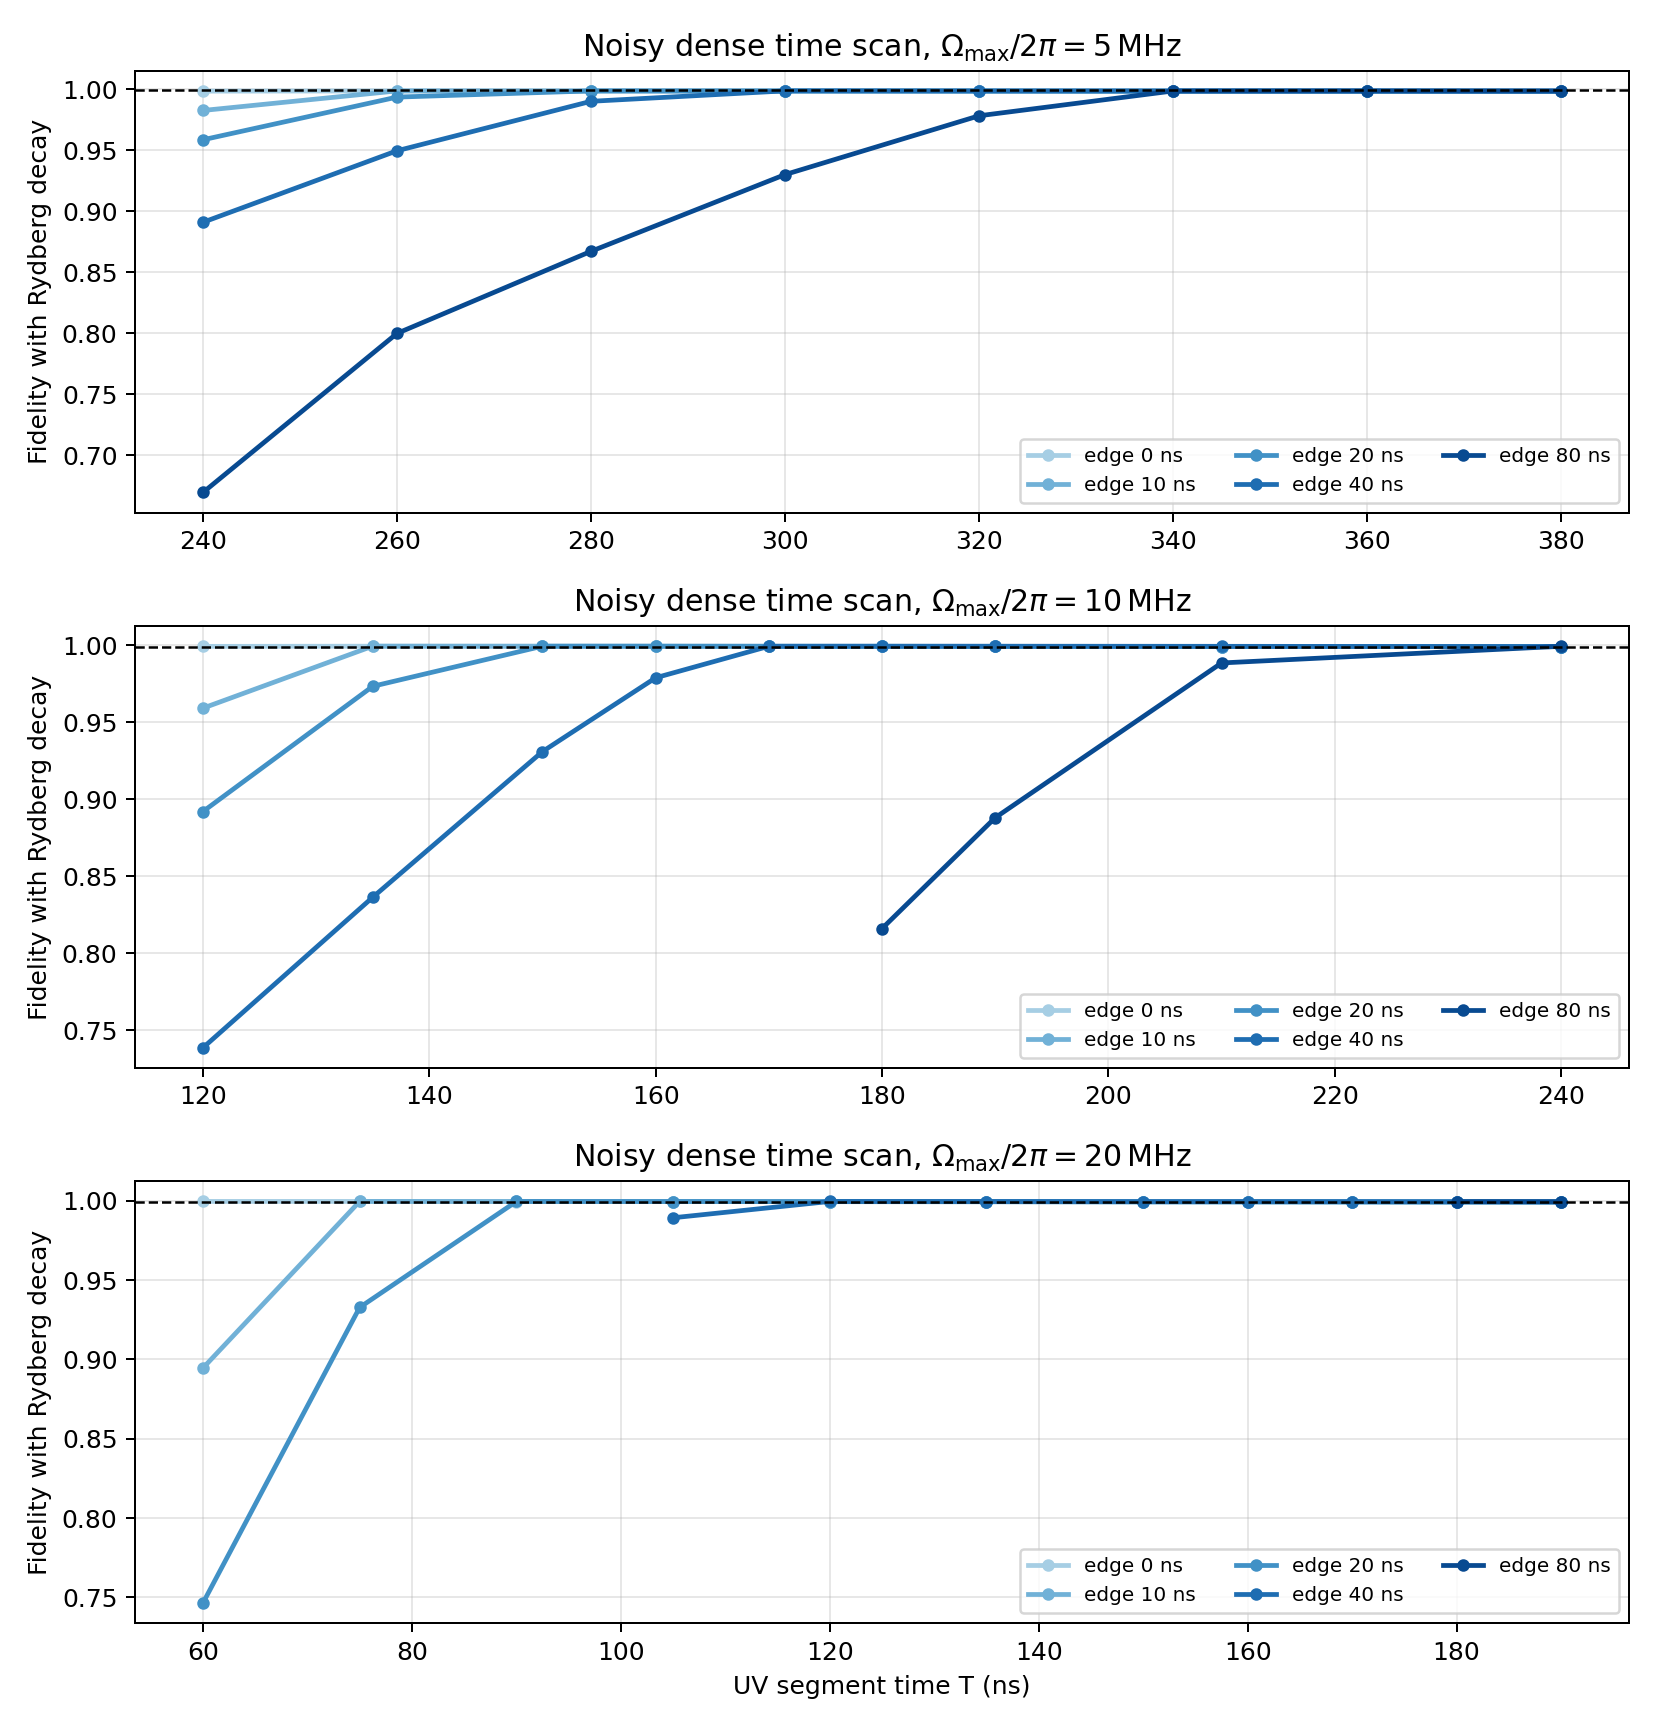

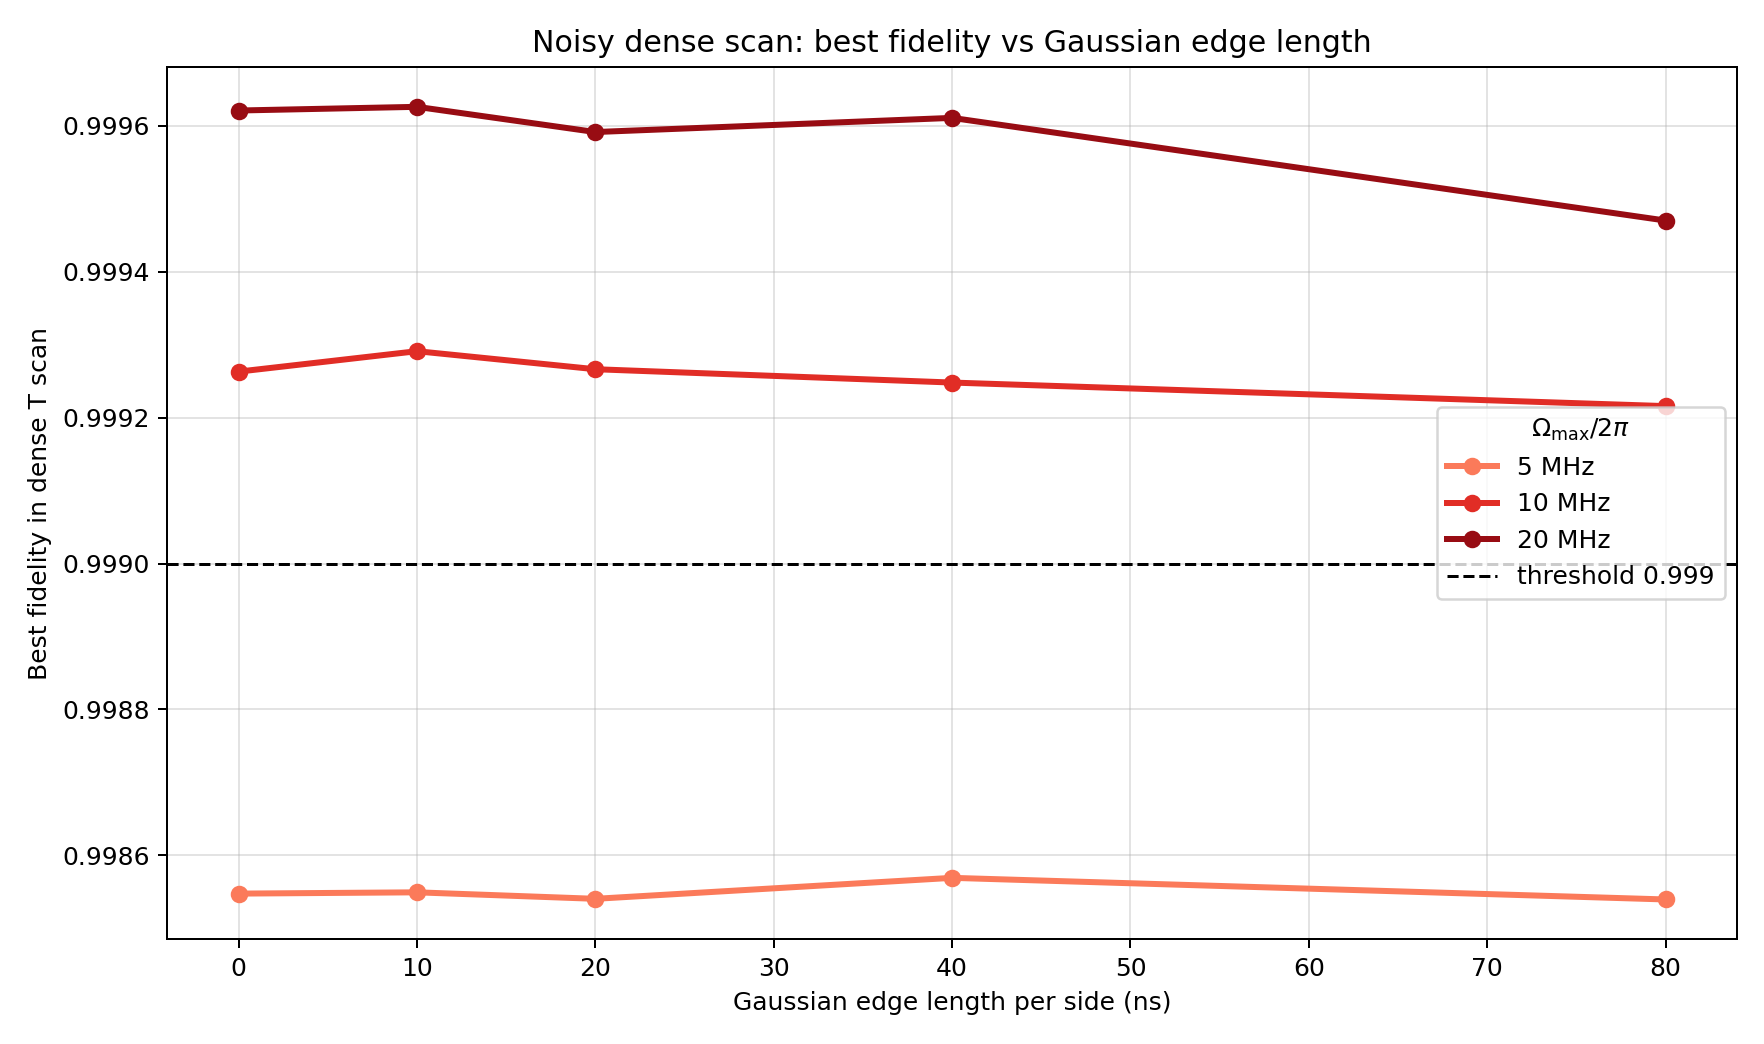

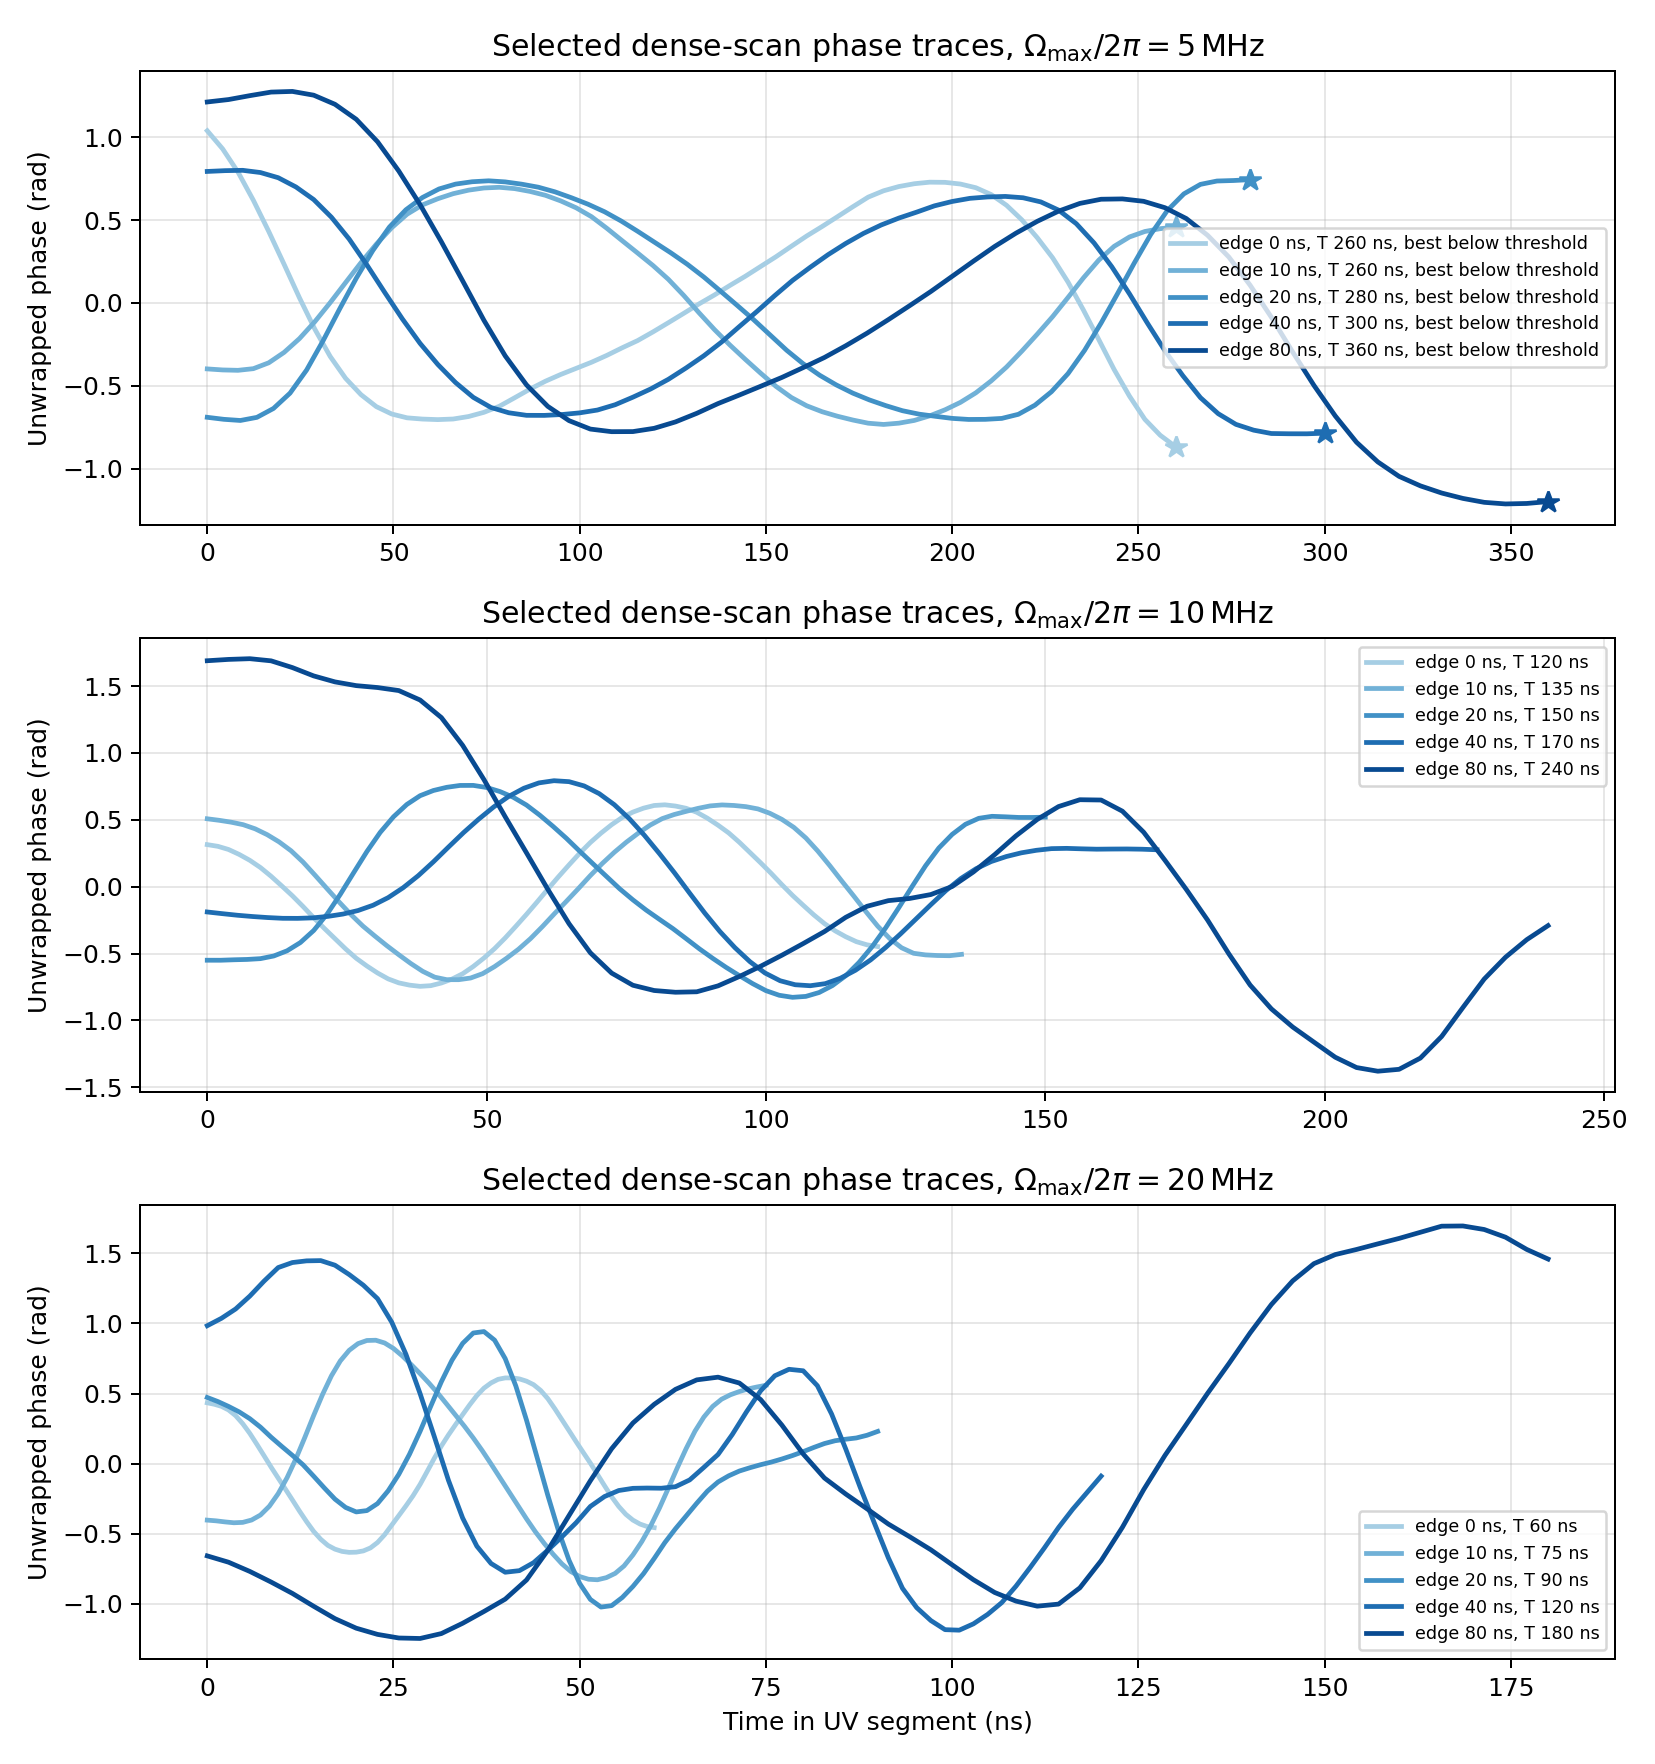

In [ ]:
from IPython.display import Image, display

for figure_name in [
    "rydberg_decay_65us_dense_fidelity_curves.png",
    "rydberg_decay_65us_dense_best_fidelity_vs_edge.png",
    "rydberg_decay_65us_dense_selected_phase_traces.png",
]:
    display(Image(filename=str(output_dir / figure_name)))


### Amplitude Envelope Example

下面的示意图直接使用上面定义的分段 Gaussian 包络函数。例子取 $\Omega_{\max}/2\pi=10\,\mathrm{MHz}$、单侧 Gaussian edge length 为 `40 ns`，总时间取该点闭系统第一个达到阈值的时间。


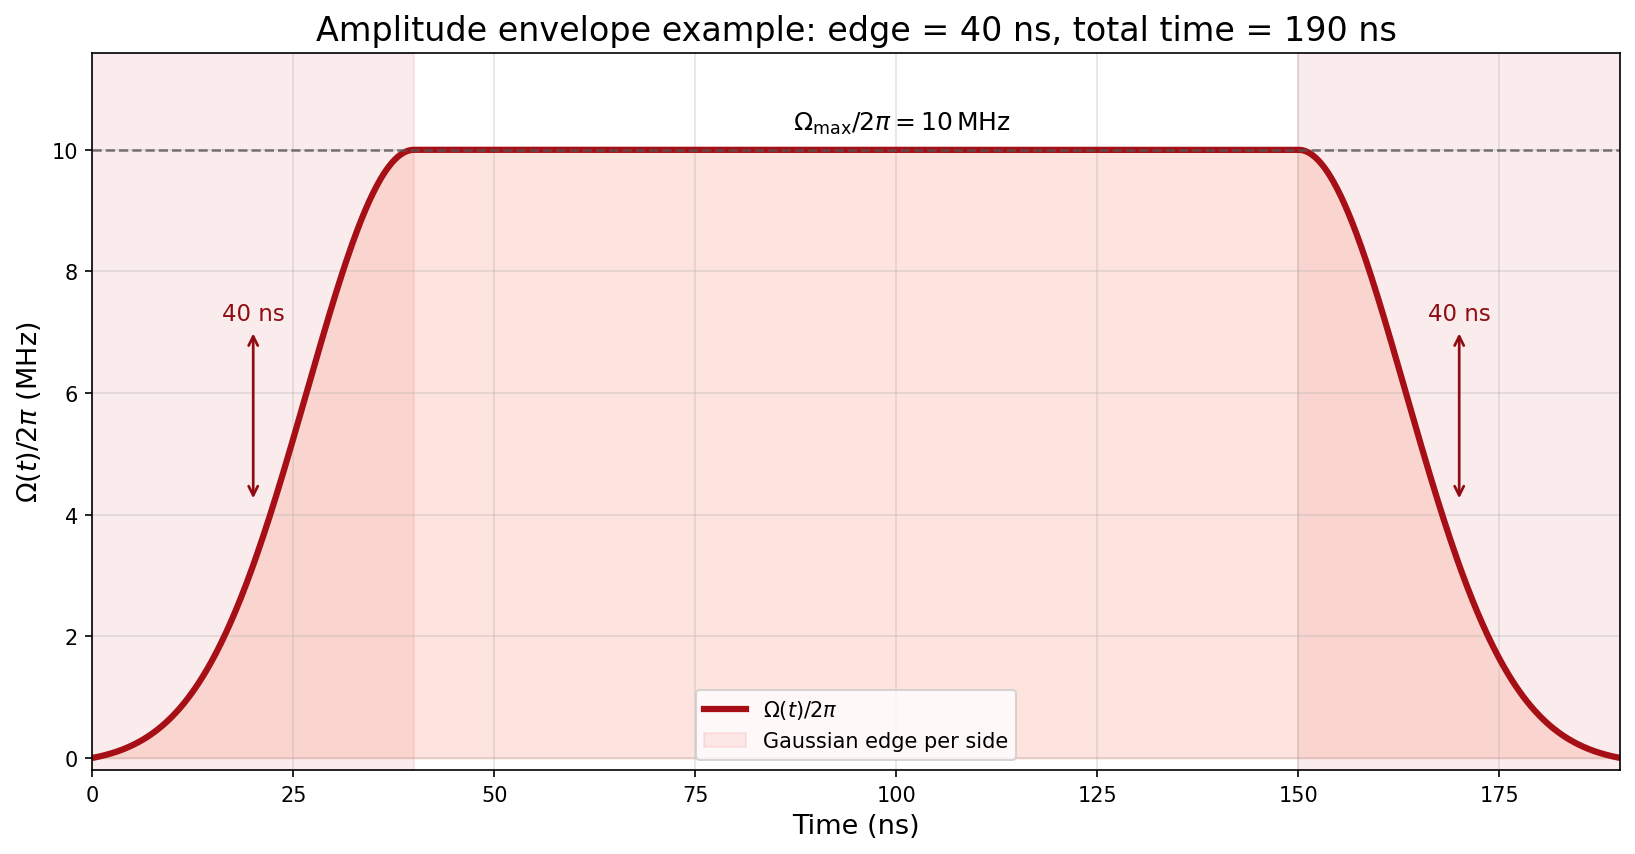

In [ ]:
summary_rows = json.loads((output_dir / "closed_cr_edge_scan_min_times.json").read_text(encoding="utf-8"))["summary"]
example = next(row for row in summary_rows if row["omega_max_mhz"] == 10.0 and row["edge_ns"] == 40.0)
example_total_time_ns = float(example["shortest_passing_time_ns"])
example_edge_ns = 40.0
example_omega_mhz = 10.0

time_grid = np.linspace(0.0, example_total_time_ns, 1200, endpoint=True)
edge = min(example_edge_ns, 0.499 * example_total_time_ns)
sigma = edge / 3.0
edge_floor = math.exp(-0.5 * (edge / sigma) ** 2)
amplitude = np.ones_like(time_grid)
left = time_grid < edge
right = time_grid > example_total_time_ns - edge
amplitude[left] = (np.exp(-0.5 * ((time_grid[left] - edge) / sigma) ** 2) - edge_floor) / (1.0 - edge_floor)
amplitude[right] = (
    np.exp(-0.5 * ((time_grid[right] - (example_total_time_ns - edge)) / sigma) ** 2) - edge_floor
) / (1.0 - edge_floor)
amplitude[0] = 0.0
amplitude[-1] = 0.0
amplitude = np.clip(amplitude, 0.0, 1.0)

fig, ax = plt.subplots(figsize=(11.0, 5.8), dpi=150)
ax.plot(time_grid, example_omega_mhz * amplitude, color="#a50f15", linewidth=3.0, label=r"$\Omega(t)/2\pi$")
ax.fill_between(time_grid, 0.0, example_omega_mhz * amplitude, color="#fb6a4a", alpha=0.18)
ax.axvspan(0.0, example_edge_ns, color="#cb181d", alpha=0.08, label="Gaussian edge per side")
ax.axvspan(example_total_time_ns - example_edge_ns, example_total_time_ns, color="#cb181d", alpha=0.08)
ax.axhline(example_omega_mhz, color="#555555", linestyle="--", linewidth=1.2, alpha=0.8)
ax.set_title(f"Amplitude envelope example: edge = 40 ns, total time = {example_total_time_ns:.0f} ns")
ax.set_xlabel("Time (ns)")
ax.set_ylabel(r"$\Omega(t)/2\pi$ (MHz)")
ax.set_xlim(0.0, example_total_time_ns)
ax.set_ylim(-0.2, example_omega_mhz * 1.16)
ax.grid(True, alpha=0.35)
ax.legend(loc="lower center", frameon=True)
fig.tight_layout()
fig.savefig(output_dir / "amplitude_envelope_omega10_edge40.png", dpi=180)
plt.close(fig)

from IPython.display import Image, display
display(Image(filename=str(output_dir / "amplitude_envelope_omega10_edge40.png")))


## Packaged API Integration

The Gaussian rising/falling edge used in this notebook is now part of the reusable package. Use `neutral_yb.models.gaussian_edge_envelope_from_times` when the edge is specified as a one-sided physical time. The helper only requires `total_time` and `edge_time` to use the same units.

For the packaged open-system GRAPE optimizer, set `control_envelope="GAUSSIAN_EDGE"` and pass `gaussian_edge_time=<one-sided edge time>`. In the calibrated `^{171}\mathrm{Yb}` model the optimizer time is dimensionless in units of `1/Omega_max`, so both `evo_time` and `gaussian_edge_time` should be converted by multiplying the physical time by `Omega_max` in angular units.


In [ ]:
from neutral_yb.models import gaussian_edge_envelope_from_times
from neutral_yb.optimization import OpenSystemGRAPEConfig

omega_max_mhz_example = 10.0
total_time_ns_example = 150.0
edge_time_ns_example = 40.0

# The reusable helper matches the notebook's original ns-based envelope.
packaged_envelope = gaussian_edge_envelope_from_times(
    num_tslots=64,
    total_time=total_time_ns_example,
    edge_time=edge_time_ns_example,
    sigma_to_edge=1.0 / 3.0,
)
notebook_envelope = gaussian_edge_envelope_ns(
    num_tslots=64,
    total_time_ns=total_time_ns_example,
    edge_time_ns=edge_time_ns_example,
    sigma_to_edge=1.0 / 3.0,
)
assert np.allclose(packaged_envelope, notebook_envelope)

# OpenSystemGRAPEConfig uses dimensionless time for the calibrated package model.
omega_rad_per_ns = 2.0 * np.pi * omega_max_mhz_example * 1.0e-3
packaged_edge_config_example = OpenSystemGRAPEConfig(
    num_tslots=64,
    evo_time=omega_rad_per_ns * total_time_ns_example,
    control_envelope="GAUSSIAN_EDGE",
    gaussian_edge_time=omega_rad_per_ns * edge_time_ns_example,
    gaussian_edge_sigma_to_edge=1.0 / 3.0,
    phase_diff_weight=1.0e-4,
)

print(
    "packaged envelope ok; edge per side = "
    f"{edge_time_ns_example:.0f} ns, "
    f"dimensionless edge = {packaged_edge_config_example.gaussian_edge_time:.6f}"
)


packaged envelope ok; edge per side = 40 ns, dimensionless edge = 2.513274


## Outputs

Kept dense no-jump process-fidelity artifact files:

- `rydberg_decay_65us_dense_time_scan_results.json`
- `rydberg_decay_65us_dense_min_times.json`
- `rydberg_decay_65us_dense_time_scan_summary.csv`
- `rydberg_decay_65us_dense_min_times.csv`
- `rydberg_decay_65us_dense_selected_phase_rows.json`
- `rydberg_decay_65us_dense_fidelity_curves.png`
- `rydberg_decay_65us_dense_best_fidelity_vs_edge.png`
- `rydberg_decay_65us_dense_selected_time_vs_edge.png`
- `rydberg_decay_65us_dense_selected_phase_traces.png`
- `amplitude_envelope_omega10_edge40.png`

In the dense noisy artifacts, `fidelity` is now the no-jump process fidelity $|\mathrm{Tr}(D_{\mathrm{CZ}}^\dagger K_{\mathrm{comp}})|^2/16$. The old average-fidelity-like proxy is retained only as `no_jump_average_fidelity`; `active_population` and `loss_proxy` remain diagnostics for no-jump norm loss.
